# Matemática IV

# Trabajo Práctico Final: Ciencia de Datos

## Análisis de Datos del Transporte Aéreo en Argentina

El repositorio con los dataset se encuentra en: https://github.com/mletelle/MateIV_Transporte_Publico/ 

**Integrantes:**  
- Baselli María  
- Fernández Emiliano  
- Letelle Mauro

# Índice
- Introducción
- Fuentes de datos
- Objetivos del análisis
- Metodología y preparación de datos
- **Análisis general del mercado aerocomercial argentino**
    - Demanda por hora, día y mes
    - Rutas y niveles de ocupación
    - Valores atípicos y evolución histórica
    - Análisis de demoras
    - Modelos binomial y Poisson
    -  Conclusiones de la Parte I
- **Análisis específico de San Carlos de Bariloche**
    -  Contexto y objetivos del caso Bariloche
    -  Estadística descriptiva
    -  Demanda mensual, horaria y semanal
    -  Modelos binomial y Poisson
    -  Modelo predictivo y feriados largos
    -  Recomendaciones
    -  Conclusiones del caso Bariloche
-  **Cierre**
    -  Conclusiones generales
    -  Limitaciones generales
-  Bibliografía


#  Análisis general del mercado aerocomercial

# Introducción

El transporte aéreo cumple un rol central en la conectividad de Argentina: reduce distancias, integra regiones, sostiene actividad turística y económica, y permite observar patrones de movilidad que no siempre son visibles en otros medios de transporte. Analizar sus datos permite responder preguntas concretas sobre demanda, ocupación, rutas relevantes y puntualidad del servicio.

Este trabajo estudia el comportamiento reciente del mercado aerocomercial argentino a partir de tres fuentes locales: conectividad aérea, movimientos aeroportuarios de ANAC e información de demoras publicada por Failbondi. El objetivo no es solo describir los datos, sino transformar esos resultados en conclusiones útiles para tomar decisiones operativas: dónde hay mayor demanda, cuándo se concentran los pasajeros, qué rutas sostienen más tráfico, qué servicios tienen alta ocupación y dónde aparecen más demoras.

Todo el análisis se ejecuta localmente desde este repositorio. Los archivos crudos se encuentran en `datasets/` y el material de limpieza previo queda como referencia en `Datasets ANALIZADOS/`.

# Fuente de datos

El notebook utiliza tres conjuntos de datos locales:

1. **Conectividad aérea**  
   Archivos: `conectividad_aerea_cabotaje.csv` y `conectividad_aerea_internacional.csv`.  
   Contienen vuelos, pasajeros, asientos, aerolíneas, rutas, origen, destino, clase de vuelo y fecha. En los archivos disponibles cubren el período **2019-2026**.

2. **Aterrizajes y despegues ANAC**  
   Archivos: `202312-informe-ministerio-actualizado-dic.csv`, `202412-informe-ministerio-actualizado-dic-final.csv`, `202512-informe-ministerio-actualizado-dic-final.csv` y `202604-informe-ministerio.csv`.
   Contienen movimientos aeroportuarios, `Pasajeros`, `PAX`, fecha, hora, aeropuerto, aerolínea, tipo de movimiento y clasificación del vuelo. En ANAC, `Pasajeros` y `PAX` no son equivalentes: `Pasajeros` mide personas por movimiento aeroportuario y `PAX` se usa como pasajeros equivalentes para demanda agregada. Los archivos disponibles cubren desde **2023 hasta abril de 2026**. Para los análisis comparativos se utilizan los años completos **2023, 2024 y 2025**. Los datos parciales de 2026 se conservan en la carga original, pero se excluyen de estos cálculos para evitar comparaciones entre períodos completos e incompletos.

3. **Failbondi**  
   Archivo: `failbondi-2026-05-20-dump.json`.  
   Contiene vuelos, aerolínea, aeropuerto, movimiento, estado, matrícula, aeronave, fecha programada y diferencia temporal respecto de la operación prevista. Como el dump fue generado en **mayo 2026**, se recortan vuelos posteriores a esa fecha para no analizar vuelos futuros como si fueran observados. El periodo del dataset abarca entonces desde el **22-12-2024** al **20/05/2026**.

Fuentes mencionadas:

- Tableros Yvera: https://tableros.yvera.tur.ar/conectividad/
- Datos abiertos ANAC: https://www.datos.gob.ar/
- Failbondi: https://failbondi.fail/acerca

## Objetivo general

Analizar datos del transporte aéreo argentino para identificar patrones de demanda, ocupación y demoras que ayuden a comprender el funcionamiento del sistema y a proponer decisiones operativas basadas en datos.

## Preguntas de análisis

1. ¿Cuál es el volumen y alcance temporal real de cada fuente?
2. ¿En qué horarios se concentra la mayor y menor demanda de pasajeros equivalentes?
3. ¿Qué días de la semana tienen más movimiento?
4. ¿Qué meses presentan mayor y menor cantidad de pasajeros equivalentes?
5. ¿Qué rutas concentran más pasajeros en cabotaje, internacional y total?
6. ¿Cómo se comporta la ocupación y qué criterio se usa para definir alta ocupación?
7. ¿Qué valores atípicos aparecen en la serie histórica y cómo se interpretan?
8. ¿Cuál es el comportamiento general de las demoras?
9. ¿Las demoras cambian según tipo de movimiento y aerolínea?
10. ¿Las demoras varían según hora del día y día de semana?
11. ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

# Metodología y decisiones de limpieza

- El análisis usa rutas locales del repositorio y no depende de servicios externos.
- Para los análisis comparativos de ANAC se utilizan los años completos 2023, 2024 y 2025. Trabajar con tres años reduce el efecto de situaciones particulares de un único período y permite obtener promedios más representativos. Los datos parciales de 2026 se conservan en la carga original, pero se excluyen de estos cálculos.
- En ANAC `Pasajeros` y `PAX` no son lo mismo. `Pasajeros` cuenta personas asociadas a cada movimiento aeroportuario (`Aterrizaje` o `Despegue`). `PAX` se usa como pasajeros equivalentes para demanda agregada: coincide con `Pasajeros` en vuelos internacionales, pero en vuelos domésticos suele ser aproximadamente la mitad para evitar duplicar cabotaje al sumar demanda.
- Failbondi se recorta hasta el 20/05/2026, fecha del dump local, para evitar vuelos futuros programados.
- Para este análisis se define como demora relevante aquella superior a 15 minutos (`delta_minutos > 15`). Este umbral permite distinguir pequeñas diferencias operativas de retrasos con mayor impacto sobre la puntualidad del servicio.
- Para limpiar demoras extremas se conservan vuelos entre `-180` y `360` minutos. El recorte evita que valores aislados dominen promedios y gráficos.
- La ocupación se calcula como `Pasajeros / Asientos`, porque mide qué proporción de asientos se ocupó en el movimiento registrado.
- Los nulos de ocupación no se pisan: se conserva `ocupacion_original`, se marca `ocupacion_fue_imputada` y se crea `ocupacion` imputada con la media de su clasificación.
- La alta ocupación no usa un umbral arbitrario. Se define por clasificación: un registro tiene alta ocupación si su ocupación es mayor o igual a la mediana de su grupo (`Cabotaje` o `Internacional`).

# Carga de librerías y rutas locales

In [1]:
from pathlib import Path  
from math import comb, exp, factorial  
import json
from scipy.stats import poisson, norm
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

try:
    from IPython.display import display
except ImportError:
    display = print

Path('.matplotlib').mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))


pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)
plt.style.use('seaborn-v0_8-whitegrid')

ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202312-informe-ministerio-actualizado-dic.csv',
    '202412-informe-ministerio-actualizado-dic-final.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

def resolver_base_dir():
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / 'datasets').is_dir():
            return carpeta
    raise FileNotFoundError(
        'No se encontró la carpeta datasets/. Abrí VS Code en la raíz del proyecto MateIV_Transporte_Publico.'
    )

BASE_DIR = resolver_base_dir()
DATA_DIR = BASE_DIR / 'datasets'
ANALIZADOS_DIR = BASE_DIR / 'Datasets ANALIZADOS'

faltantes = [archivo for archivo in ARCHIVOS_REQUERIDOS if not (DATA_DIR / archivo).is_file()]
if faltantes:
    mensaje = 'Faltan archivos en datasets/:' + chr(10) + '- ' + (chr(10) + '- ').join(faltantes)
    raise FileNotFoundError(mensaje)

print('Archivos encontrados:')
for archivo in sorted(p.name for p in DATA_DIR.iterdir() if p.is_file()):
    print('-', archivo)

Archivos encontrados:
- 202312-informe-ministerio-actualizado-dic.csv
- 202412-informe-ministerio-actualizado-dic-final.csv
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga y preparación de datos

In [2]:
MESES = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12,
}

DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo',
}

ORDEN_DIAS = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
FECHA_CORTE_FAILBONDI = pd.Timestamp('2026-05-20 23:59:59', tz='UTC')


def leer_conectividad(nombre_archivo, clasificacion):
    df = pd.read_csv(DATA_DIR / nombre_archivo)
    df.columns = df.columns.str.strip()
    df['Clasificacion'] = clasificacion
    df['mes_num'] = df['Mes'].map(MESES)
    df['fecha'] = pd.to_datetime(
        dict(year=df['Año'], month=df['mes_num'], day=df['Dia']),
        errors='coerce'
    )
    df['anio'] = df['fecha'].dt.year
    df['ocupacion_original'] = np.where(df['Asientos'] > 0, df['Pasajeros'] / df['Asientos'], np.nan)
    return df


def leer_anac(nombre_archivo):
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    df.columns = df.columns.str.strip()

    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    df['pasajeros_movimiento'] = df['Pasajeros']
    df['pasajeros_equivalentes'] = df['PAX']

    df['Fecha UTC'] = pd.to_datetime(df['Fecha UTC'], dayfirst=True, errors='coerce')
    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month
    df['dia_semana'] = df['Fecha UTC'].dt.day_name().map(DIAS)
    df['hora'] = pd.to_datetime(df['Hora UTC'], format='%H:%M', errors='coerce').dt.hour
    return df


def cargar_failbondi(path, chunk_size=1024 * 1024):
    registros = []
    decoder = json.JSONDecoder()
    buffer = ''
    dentro_array = False
    fin = False

    with open(path, encoding='utf-8', errors='replace') as archivo:
        while not fin:
            chunk = archivo.read(chunk_size)
            if chunk == '':
                fin = True
            buffer += chunk

            while True:
                buffer = buffer.lstrip()

                if not dentro_array:
                    if not buffer:
                        break
                    if buffer[0] != '[':
                        raise ValueError('El JSON de Failbondi no empieza con un array.')
                    buffer = buffer[1:]
                    dentro_array = True
                    buffer = buffer.lstrip()

                if buffer.startswith(']'):
                    fin = True
                    break

                if buffer.startswith(','):
                    buffer = buffer[1:].lstrip()

                if not buffer:
                    break

                try:
                    item, idx = decoder.raw_decode(buffer)
                except json.JSONDecodeError:
                    break

                raw = item.get('json') or {}
                registros.append({
                    'flight_id': item.get('aerolineas_flight_id'),
                    'fecha_programada': item.get('stda_parsed'),
                    'aeropuerto': raw.get('arpt'),
                    'movimiento': raw.get('mov'),
                    'nro_vuelo': raw.get('nro'),
                    'aerolinea': raw.get('aerolinea'),
                    'destino_origen': raw.get('destorig'),
                    'estado': raw.get('estes'),
                    'matricula': item.get('matricula'),
                    'aeronave': item.get('aeronave'),
                    'edad_avion': item.get('edad_del_avion'),
                    'delta_segundos': item.get('delta'),
                })
                buffer = buffer[idx:]

    df = pd.DataFrame(registros)
    df['fecha_programada'] = pd.to_datetime(df['fecha_programada'], errors='coerce')
    df['delta_segundos'] = pd.to_numeric(df['delta_segundos'], errors='coerce')
    df['delta_minutos'] = df['delta_segundos'] / 60
    df['demorado_15m'] = df['delta_minutos'] > 15
    df['adelantado_5m'] = df['delta_minutos'] < -5
    df['fecha'] = df['fecha_programada'].dt.date
    df['hora'] = df['fecha_programada'].dt.hour
    df['dia_semana'] = df['fecha_programada'].dt.day_name().map(DIAS)
    df['tipo_movimiento'] = df['movimiento'].map({'A': 'Arribo', 'D': 'Partida'}).fillna(df['movimiento'])
    return df

conectividad = pd.concat([
    leer_conectividad('conectividad_aerea_cabotaje.csv', 'Cabotaje'),
    leer_conectividad('conectividad_aerea_internacional.csv', 'Internacional'),
], ignore_index=True)

media_ocupacion_por_clase = conectividad.groupby('Clasificacion')['ocupacion_original'].transform('mean')
conectividad['ocupacion_fue_imputada'] = conectividad['ocupacion_original'].isna()
conectividad['ocupacion'] = conectividad['ocupacion_original'].fillna(media_ocupacion_por_clase)

umbral_alta_ocupacion = conectividad.groupby('Clasificacion')['ocupacion'].median()
conectividad['umbral_alta_ocupacion'] = conectividad['Clasificacion'].map(umbral_alta_ocupacion)
conectividad['alta_ocupacion'] = conectividad['ocupacion'] >= conectividad['umbral_alta_ocupacion']

anac = pd.concat([
    leer_anac('202312-informe-ministerio-actualizado-dic.csv'),
    leer_anac('202412-informe-ministerio-actualizado-dic-final.csv'),
    leer_anac('202512-informe-ministerio-actualizado-dic-final.csv'),
    leer_anac('202604-informe-ministerio.csv'),
], ignore_index=True)
anac_2023_2025 = anac[anac['anio'].isin([2023, 2024, 2025])].copy()

failbondi_raw = cargar_failbondi(DATA_DIR / 'failbondi-2026-05-20-dump.json')
failbondi = failbondi_raw[failbondi_raw['fecha_programada'] <= FECHA_CORTE_FAILBONDI].copy()
failbondi_limpio = failbondi[failbondi['delta_minutos'].between(-180, 360)].copy()

print('Datos cargados y preparados.')

Datos cargados y preparados.


## Diferencia entre Pasajeros y PAX en ANAC
No son lo mismo en este dataset.
Pasajeros: Cuenta pasajeros asociados a un Aterrizaje o a un Despegue. Es una variable de operación/movimiento. 
PAX: En vuelos internacionales coincide con Pasajeros. En vuelos domésticos suele ser aproximadamente la mitad de Pasajeros, porque el sistema puede registrar el viaje dentro del país en dos movimientos nacionales: salida y llegada. 
Ejemplo real del archivo ANAC: si un movimiento doméstico tiene Pasajeros = 167, aparece PAX = 83.5. En internacional, si Pasajeros = 281, aparece PAX = 281.
Por eso no se mezclan como sinónimos:
- Para **demanda agregada** se usa PAX / pasajeros_equivalentes.
- Para **pasajeros asociados a un movimiento** se usa Pasajeros / pasajeros_movimiento.
- Para **ocupación** se usa Pasajeros / Asientos, porque la ocupación corresponde al movimiento registrado.


In [3]:
comparacion_pax = anac.groupby('Clasificación Vuelo').agg(
    pasajeros_movimiento=('pasajeros_movimiento', 'sum'),
    pasajeros_equivalentes=('pasajeros_equivalentes', 'sum'),
).reset_index()
comparacion_pax['relacion_pasajeros_sobre_pax'] = (
    comparacion_pax['pasajeros_movimiento'] / comparacion_pax['pasajeros_equivalentes']
)

muestra_pax = anac[[
    'Fecha UTC',
    'Tipo de Movimiento',
    'Clasificación Vuelo',
    'pasajeros_movimiento',
    'pasajeros_equivalentes',
]].head(8)

print('Comparación acumulada por clasificación')
display(comparacion_pax)




Comparación acumulada por clasificación


,Clasificación Vuelo,pasajeros_movimiento,pasajeros_equivalentes,relacion_pasajeros_sobre_pax
0,Doméstico,113009673.0,56526987.0,1.999216
1,Internacional,47836075.0,47836075.0,1.000000


Conclusión: en ANAC, Pasajeros y PAX no son sinónimos. En internacional coinciden, pero en doméstico Pasajeros es casi el doble de PAX. Por eso el análisis de demanda agregada usa PAX como pasajeros_equivalentes, mientras que Pasajeros queda como pasajeros_movimiento.

# ¿Cuál es el volumen y alcance temporal real de cada fuente?

In [4]:
resumen_datasets = pd.DataFrame([
    {
        'fuente': 'Conectividad',
        'filas': len(conectividad),
        'columnas': conectividad.shape[1],
        'fecha_inicio': conectividad['fecha'].min().date(),
        'fecha_fin': conectividad['fecha'].max().date(),
        'uso_en_analisis': 'Serie 2019-2026; para tendencias anuales se excluye 2026 parcial',
    },
    {
        'fuente': 'ANAC aterrizajes/despegues',
        'filas': len(anac),
        'columnas': anac.shape[1],
        'fecha_inicio': anac['Fecha UTC'].min().date(),
        'fecha_fin': anac['Fecha UTC'].max().date(),
        'uso_en_analisis': 'Se usa 2023-2025 completo para hora, día y mes',
    },
    {
        'fuente': 'Failbondi recortado al dump',
        'filas': len(failbondi),
        'columnas': failbondi.shape[1],
        'fecha_inicio': failbondi['fecha_programada'].min().date(),
        'fecha_fin': failbondi['fecha_programada'].max().date(),
        'uso_en_analisis': 'Se excluyen vuelos posteriores al 20/05/2026',
    },
    {
        'fuente': 'Failbondi limpio para demoras',
        'filas': len(failbondi_limpio),
        'columnas': failbondi_limpio.shape[1],
        'fecha_inicio': failbondi_limpio['fecha_programada'].min().date(),
        'fecha_fin': failbondi_limpio['fecha_programada'].max().date(),
        'uso_en_analisis': 'Se conservan demoras entre -180 y 360 minutos',
    },
])

display(resumen_datasets)

filas_futuras_failbondi = len(failbondi_raw) - len(failbondi)
porcentaje_conservado_demoras = len(failbondi_limpio) / len(failbondi) * 100

print(
    f"Conclusión: el análisis combina fuentes con distinto alcance temporal. "
    f"ANAC se analiza sobre 2023/2024/2025 completo y Failbondi se recorta al 20/05/2026; "
    f"se excluyeron {filas_futuras_failbondi:,} vuelos futuros del dump y se conservó "
    f"{porcentaje_conservado_demoras:.2f}% de los registros observados para demoras."
)

,fuente,filas,columnas,fecha_inicio,fecha_fin,uso_en_analisis
0,Conectividad,765333,29,2019-01-01,2026-04-30,Serie 2019-2026; para tendencias anuales se ex...
1,ANAC aterrizajes/despegues,1930858,18,2023-01-01,2026-04-30,"Se usa 2023-2025 completo para hora, día y mes"
2,Failbondi recortado al dump,358711,19,2024-01-01,2026-05-20,Se excluyen vuelos posteriores al 20/05/2026
3,Failbondi limpio para demoras,336687,19,2024-12-22,2026-05-20,Se conservan demoras entre -180 y 360 minutos


Conclusión: el análisis combina fuentes con distinto alcance temporal. ANAC se analiza sobre 2023/2024/2025 completo y Failbondi se recorta al 20/05/2026; se excluyeron 2 vuelos futuros del dump y se conservó 93.86% de los registros observados para demoras.


# ¿En qué horarios se concentra la mayor y menor demanda de pasajeros equivalentes?

### Promedio por hora durante el período 2023-2025

,hora,pasajeros_equivalentes
0,0,1.667830e+06
1,1,1.331691e+06
2,2,1.135852e+06
3,3,1.010638e+06
4,4,6.078655e+05
5,5,4.530318e+05
6,6,5.216313e+05
7,7,6.791607e+05
8,8,8.398862e+05
9,9,1.033595e+06


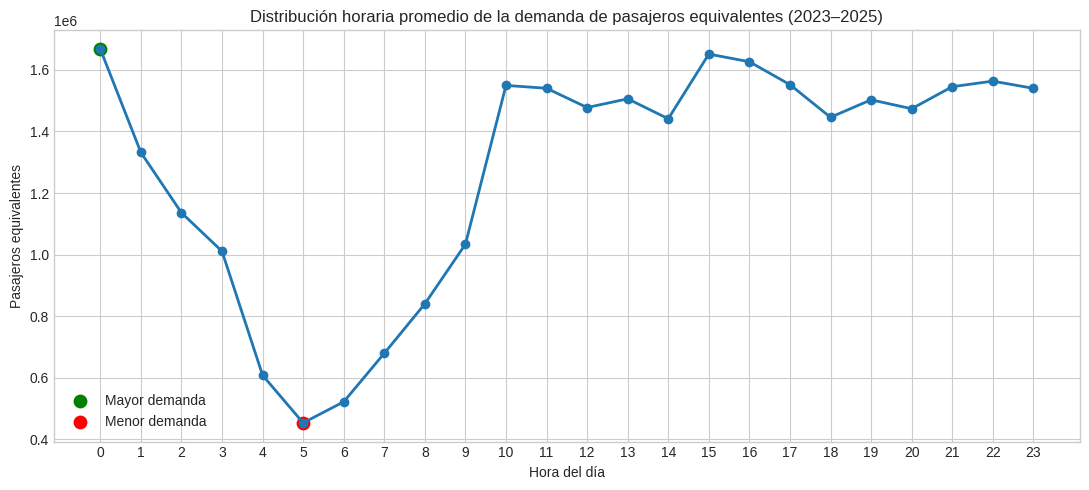

Conclusión: la mayor demanda se concentra a las 0:00 con 1,667,830 pasajeros equivalentes; la menor ocurre a las 5:00 con 453,032 pasajeros equivalentes. Esto sirve para identificar franjas donde reforzar capacidad operativa.


In [5]:
pax_por_hora = (
    anac_2023_2025.groupby(['anio', 'hora'])['pasajeros_equivalentes']
    .sum()
    .reset_index()
    .groupby('hora')['pasajeros_equivalentes']
    .mean()
    .reindex(range(24), fill_value=0)
    .reset_index()
)
pax_por_hora.columns = ['hora', 'pasajeros_equivalentes']

hora_max = pax_por_hora.loc[pax_por_hora['pasajeros_equivalentes'].idxmax()]
hora_min = pax_por_hora.loc[pax_por_hora['pasajeros_equivalentes'].idxmin()]

display(
    pax_por_hora[['hora', 'pasajeros_equivalentes']]
    .style.format({'pasajeros_equivalentes': '{:,.0f}'})
)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pax_por_hora['hora'], pax_por_hora['pasajeros_equivalentes'], marker='o', linewidth=2)
ax.scatter([hora_max['hora']], [hora_max['pasajeros_equivalentes']], color='green', s=80, label='Mayor demanda')
ax.scatter([hora_min['hora']], [hora_min['pasajeros_equivalentes']], color='red', s=80, label='Menor demanda')
ax.set_title('Distribución horaria promedio de la demanda de pasajeros equivalentes (2023–2025)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Pasajeros equivalentes')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Conclusión: la mayor demanda se concentra a las {int(hora_max['hora'])}:00 "
    f"con {hora_max['pasajeros_equivalentes']:,.0f} pasajeros equivalentes; la menor ocurre a las {int(hora_min['hora'])}:00 "
    f"con {hora_min['pasajeros_equivalentes']:,.0f} pasajeros equivalentes. Esto sirve para identificar franjas donde reforzar capacidad operativa."
)


# ¿Qué días de la semana tienen más movimiento?

### Promedio de pasajeros equivalentes por día de la semana durante 2023-2025

,dia_semana,pasajeros_equivalentes
0,Lunes,4.560728e+06
1,Martes,4.200631e+06
2,Miércoles,4.192879e+06
3,Jueves,4.327149e+06
4,Viernes,4.437111e+06
5,Sábado,4.585651e+06
6,Domingo,4.393664e+06


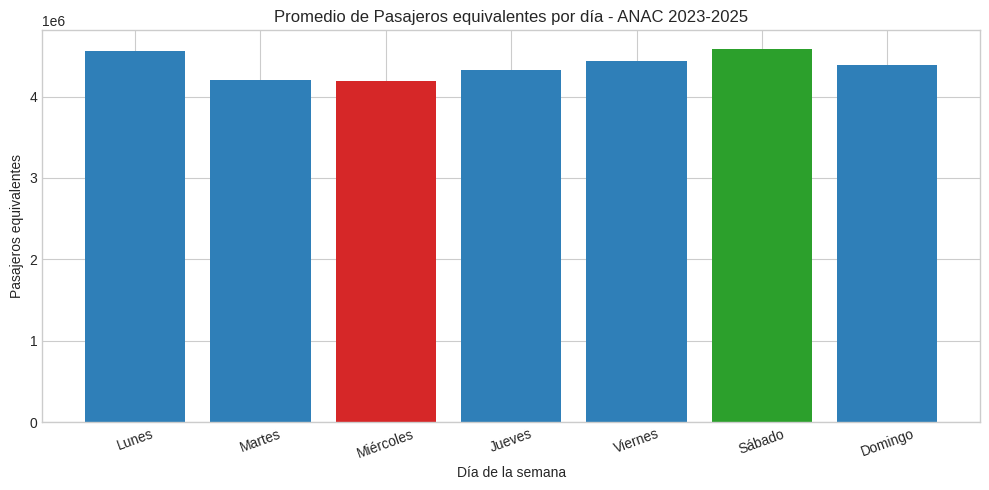

Conclusión: el día con más movimiento es Sábado (4,585,651 pasajeros equivalentes) y el menor es Miércoles (4,192,879 pasajeros equivalentes). La demanda semanal es relativamente pareja, pero el ranking ayuda a planificar recursos.


In [6]:
pax_por_dia = (
    anac_2023_2025.groupby(['anio', 'dia_semana'])['pasajeros_equivalentes']
    .sum()  # suma dentro de cada año
    .reset_index()
    .groupby('dia_semana')['pasajeros_equivalentes']
    .mean()  # promedio entre años
    .reindex(ORDEN_DIAS)  # mantener orden lunes->domingo
    .reset_index()
)

dia_max = pax_por_dia.loc[pax_por_dia['pasajeros_equivalentes'].idxmax()]
dia_min = pax_por_dia.loc[pax_por_dia['pasajeros_equivalentes'].idxmin()]

display(pax_por_dia)

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#2f7fb8' if dia not in [dia_max['dia_semana'], dia_min['dia_semana']] else '#2ca02c' if dia == dia_max['dia_semana'] else '#d62728' for dia in pax_por_dia['dia_semana']]
ax.bar(pax_por_dia['dia_semana'], pax_por_dia['pasajeros_equivalentes'], color=colores)
ax.set_title('Promedio de Pasajeros equivalentes por día - ANAC 2023-2025')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Pasajeros equivalentes')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(
    f"Conclusión: el día con más movimiento es {dia_max['dia_semana']} "
    f"({dia_max['pasajeros_equivalentes']:,.0f} pasajeros equivalentes) y el menor es {dia_min['dia_semana']} "
    f"({dia_min['pasajeros_equivalentes']:,.0f} pasajeros equivalentes). La demanda semanal es relativamente pareja, pero el ranking ayuda a planificar recursos."
)

# ¿Qué meses presentan mayor y menor cantidad de pasajeros equivalentes?

## Promedio de pasajeros equivalentes correspondiente al periodo 2023-2025

,mes,mes_nombre,pasajeros_equivalentes
0,1,Enero,2733964
1,2,Febrero,2468930
2,3,Marzo,2612153
3,4,Abril,2307785
4,5,Mayo,2252120
5,6,Junio,2240804
6,7,Julio,2716748
7,8,Agosto,2615551
8,9,Septiembre,2501168
9,10,Octubre,2636232


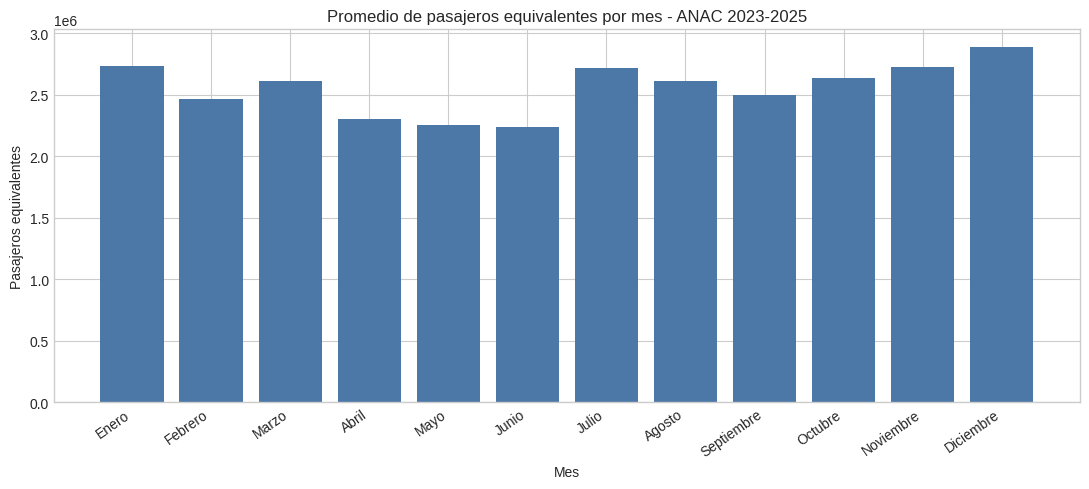

Conclusión: el mes con mayor movimiento fue Diciembre (2,888,626 pasajeros equivalentes) y el menor fue Junio (2,240,804 pasajeros equivalentes). Esta estacionalidad es útil para anticipar capacidad y demanda turística.


In [7]:
pax_por_mes = (
    anac_2023_2025.groupby(['anio', 'mes'])['pasajeros_equivalentes']
    .sum()  # total mensual por año
    .reset_index()
    .groupby('mes')['pasajeros_equivalentes']
    .mean()  # promedio entre años
    .reindex(range(1, 13), fill_value=0)
    .reset_index()
)


mes_max = pax_por_mes.loc[pax_por_mes['pasajeros_equivalentes'].idxmax()]
mes_min = pax_por_mes.loc[pax_por_mes['pasajeros_equivalentes'].idxmin()]

nombres_meses = {v: k for k, v in MESES.items()}
pax_por_mes['mes_nombre'] = pax_por_mes['mes'].map(nombres_meses)

pax_por_mes['pasajeros_equivalentes'] = pax_por_mes['pasajeros_equivalentes'].round().astype(int)
display(pax_por_mes[['mes', 'mes_nombre', 'pasajeros_equivalentes']])

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(pax_por_mes['mes_nombre'], pax_por_mes['pasajeros_equivalentes'], color='#4c78a8')
ax.set_title('Promedio de pasajeros equivalentes por mes - ANAC 2023-2025')
ax.set_xlabel('Mes')
ax.set_ylabel('Pasajeros equivalentes')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print(
    f"Conclusión: el mes con mayor movimiento fue {nombres_meses[int(mes_max['mes'])]} "
    f"({mes_max['pasajeros_equivalentes']:,.0f} pasajeros equivalentes) y el menor fue {nombres_meses[int(mes_min['mes'])]} "
    f"({mes_min['pasajeros_equivalentes']:,.0f} pasajeros equivalentes). Esta estacionalidad es útil para anticipar capacidad y demanda turística."
)

# ¿Qué rutas concentran más pasajeros en cabotaje, internacional y total?

Se separa el ranking total, cabotaje e internacional para no mezclar mercados con comportamientos distintos.

Top 5 total


,Ruta,vuelos,pasajeros,asientos,ocupacion
166,Ciudad de Buenos Aires - San Carlos de Bariloche,49340,7419737,8327601,0.890981
113,Ciudad de Buenos Aires - Córdoba,54665,7250899,8484891,0.854566
134,Ciudad de Buenos Aires - Mendoza,51294,6855503,7940252,0.863386
149,Ciudad de Buenos Aires - Puerto Iguazú,41061,5796423,6604628,0.877631
398,Ezeiza - Madrid,19451,5496882,6168319,0.891147


Top 5 cabotaje


,Clasificacion,Ruta,vuelos,pasajeros,asientos,ocupacion
42,Cabotaje,Ciudad de Buenos Aires - San Carlos de Bariloche,49340,7419737,8327601,0.890981
21,Cabotaje,Ciudad de Buenos Aires - Córdoba,54665,7250899,8484891,0.854566
27,Cabotaje,Ciudad de Buenos Aires - Mendoza,51294,6855503,7940252,0.863386
32,Cabotaje,Ciudad de Buenos Aires - Puerto Iguazú,41061,5796423,6604628,0.877631
41,Cabotaje,Ciudad de Buenos Aires - Salta,32324,4440652,5029121,0.882988


Top 5 internacional


,Clasificacion,Ruta,vuelos,pasajeros,asientos,ocupacion
581,Internacional,Ezeiza - Madrid,19451,5496882,6168319,0.891147
469,Internacional,Ciudad de Buenos Aires - São Paulo,33629,4911109,5831186,0.842214
645,Internacional,Ezeiza - São Paulo,28812,4906795,6664186,0.736293
637,Internacional,Ezeiza - Santiago,29924,4581682,6062680,0.755719
588,Internacional,Ezeiza - Miami,18006,4257932,4813803,0.884526


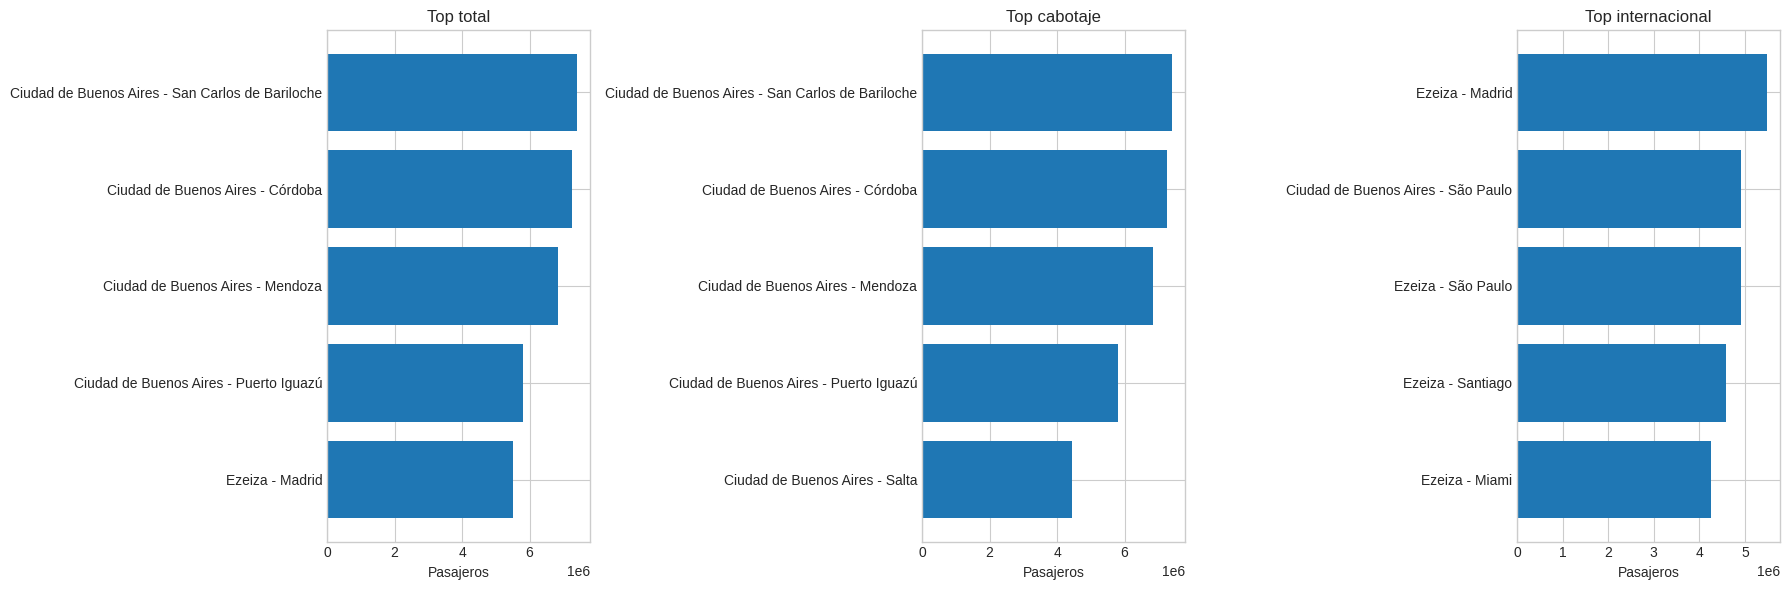

Conclusión: la ruta con mayor volumen total es Ciudad de Buenos Aires - San Carlos de Bariloche (7,419,737 pasajeros). En cabotaje lidera Ciudad de Buenos Aires - San Carlos de Bariloche y en internacional Ezeiza - Madrid. Estas rutas son candidatas naturales para reforzar capacidad, frecuencias o seguimiento operativo.


In [8]:
top_rutas = conectividad.groupby(['Clasificacion', 'Ruta']).agg(
    vuelos=('Vuelos', 'sum'),
    pasajeros=('Pasajeros', 'sum'),
    asientos=('Asientos', 'sum'),
).reset_index()
top_rutas['ocupacion'] = np.where(top_rutas['asientos'] > 0, top_rutas['pasajeros'] / top_rutas['asientos'], np.nan)

top_total = (
    top_rutas.groupby('Ruta').agg(
        vuelos=('vuelos', 'sum'),
        pasajeros=('pasajeros', 'sum'),
        asientos=('asientos', 'sum')
    )
    .reset_index()
)
top_total['ocupacion'] = top_total['pasajeros'] / top_total['asientos']
top_total = top_total.sort_values('pasajeros', ascending=False).head(5)

top_cabotaje = top_rutas[top_rutas['Clasificacion'] == 'Cabotaje'].sort_values('pasajeros', ascending=False).head(5)
top_internacional = top_rutas[top_rutas['Clasificacion'] == 'Internacional'].sort_values('pasajeros', ascending=False).head(5)

print('Top 5 total')
display(top_total)
print('Top 5 cabotaje')
display(top_cabotaje)
print('Top 5 internacional')
display(top_internacional)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, datos, titulo in [
    (axes[0], top_total.sort_values('pasajeros'), 'Top total'),
    (axes[1], top_cabotaje.sort_values('pasajeros'), 'Top cabotaje'),
    (axes[2], top_internacional.sort_values('pasajeros'), 'Top internacional'),
]:
    ax.barh(datos['Ruta'], datos['pasajeros'])
    ax.set_title(titulo)
    ax.set_xlabel('Pasajeros')
plt.tight_layout()
plt.show()

ruta_total = top_total.iloc[0]
ruta_cabotaje = top_cabotaje.iloc[0]
ruta_internacional = top_internacional.iloc[0]
print(
    f"Conclusión: la ruta con mayor volumen total es {ruta_total['Ruta']} "
    f"({ruta_total['pasajeros']:,.0f} pasajeros). En cabotaje lidera {ruta_cabotaje['Ruta']} "
    f"y en internacional {ruta_internacional['Ruta']}. Estas rutas son candidatas naturales para reforzar capacidad, frecuencias o seguimiento operativo."
)

# ¿Cómo se comporta la ocupación y cómo se define alta ocupación?

La alta ocupación se define con la mediana de cada clasificación. Esto evita usar un umbral único que podría no representar igual a cabotaje e internacional.

,Clasificacion,registros,vuelos,pasajeros,asientos,ocupacion_media,ocupacion_mediana,registros_imputados,proporcion_alta_ocupacion
0,Cabotaje,446911,787985,95117060,113020355,81.425757,85.338346,7,50.008838
1,Internacional,318422,458334,75014530,91510101,80.799683,85.393258,69,50.001884


,Clasificacion,umbral_alta_ocupacion_%
0,Cabotaje,85.338346
1,Internacional,85.393258


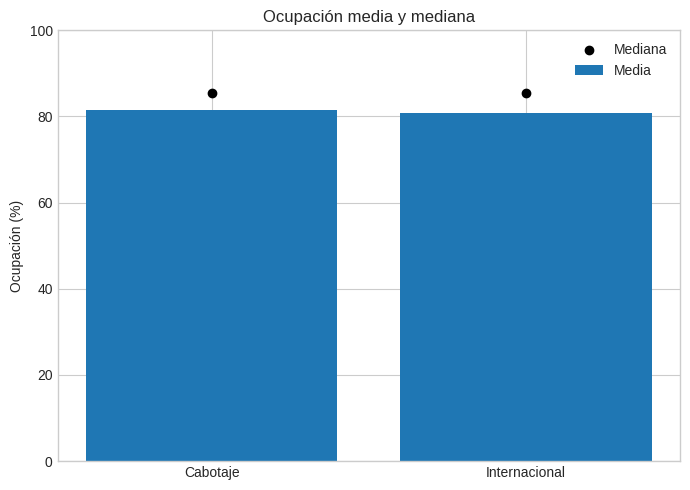

Conclusión: se imputaron 76 valores nulos de ocupación con la media de su clasificación. La ocupación es alta en ambos segmentos y el KPI de alta ocupación queda definido por la mediana propia de cada grupo, no por un valor arbitrario.


In [9]:
resumen_ocupacion = conectividad.groupby('Clasificacion').agg(
    registros=('Ruta', 'count'),
    vuelos=('Vuelos', 'sum'),
    pasajeros=('Pasajeros', 'sum'),
    asientos=('Asientos', 'sum'),
    ocupacion_media=('ocupacion', 'mean'),
    ocupacion_mediana=('ocupacion', 'median'),
    registros_imputados=('ocupacion_fue_imputada', 'sum'),
    proporcion_alta_ocupacion=('alta_ocupacion', 'mean'),
).reset_index()

for columna in [
    'ocupacion_media',
    'ocupacion_mediana',
    'proporcion_alta_ocupacion'
]:
    resumen_ocupacion[columna] *= 100

umbral_df = (umbral_alta_ocupacion * 100).rename('umbral_alta_ocupacion_%').reset_index()

display(resumen_ocupacion)
display(umbral_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    resumen_ocupacion['Clasificacion'],
    resumen_ocupacion['ocupacion_media'],
    label='Media'
)
ax.scatter(
    resumen_ocupacion['Clasificacion'],
    resumen_ocupacion['ocupacion_mediana'],
    color='black',
    label='Mediana'
)
ax.set_title('Ocupación media y mediana')
ax.set_ylabel('Ocupación (%)')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

imputados = int(conectividad['ocupacion_fue_imputada'].sum())
print(
    f"Conclusión: se imputaron {imputados} valores nulos de ocupación con la media de su clasificación. "
    f"La ocupación es alta en ambos segmentos y el KPI de alta ocupación queda definido por la mediana propia de cada grupo, "
    f"no por un valor arbitrario."
)

# ¿Qué valores atípicos aparecen en la serie histórica y cómo se interpretan?

Se observan pasajeros anuales hasta 2025 para evitar que 2026 parcial distorsione la tendencia. Además se revisan días extremos para detectar caídas, picos y posibles registros atípicos.

Pasajeros anuales por clasificación


,anio,Clasificacion,Pasajeros
0,2019,Cabotaje,15965999
1,2019,Internacional,14294082
2,2020,Cabotaje,3600497
3,2020,Internacional,3367484
4,2021,Cabotaje,6037412
5,2021,Internacional,1947298
6,2022,Cabotaje,13454917
7,2022,Internacional,8093235
8,2023,Cabotaje,17229196
9,2023,Internacional,11668342


Días con pasajeros muy bajos, excluyendo 2026 parcial


,fecha,Pasajeros
508,2020-05-28,17
473,2020-04-21,25
589,2020-08-22,50
619,2020-09-21,51
549,2020-07-09,55
476,2020-04-24,65
478,2020-04-26,78
533,2020-06-22,89
568,2020-08-01,133
592,2020-08-25,133


Días con pasajeros muy altos, excluyendo 2026 parcial


,fecha,Pasajeros
2543,2025-12-28,117294
2534,2025-12-19,111009
2536,2025-12-21,110376
2535,2025-12-20,110246
2241,2025-03-01,109396
2545,2025-12-30,108712
2529,2025-12-14,108698
2214,2025-02-02,106905
2544,2025-12-29,106750
2185,2025-01-04,106716


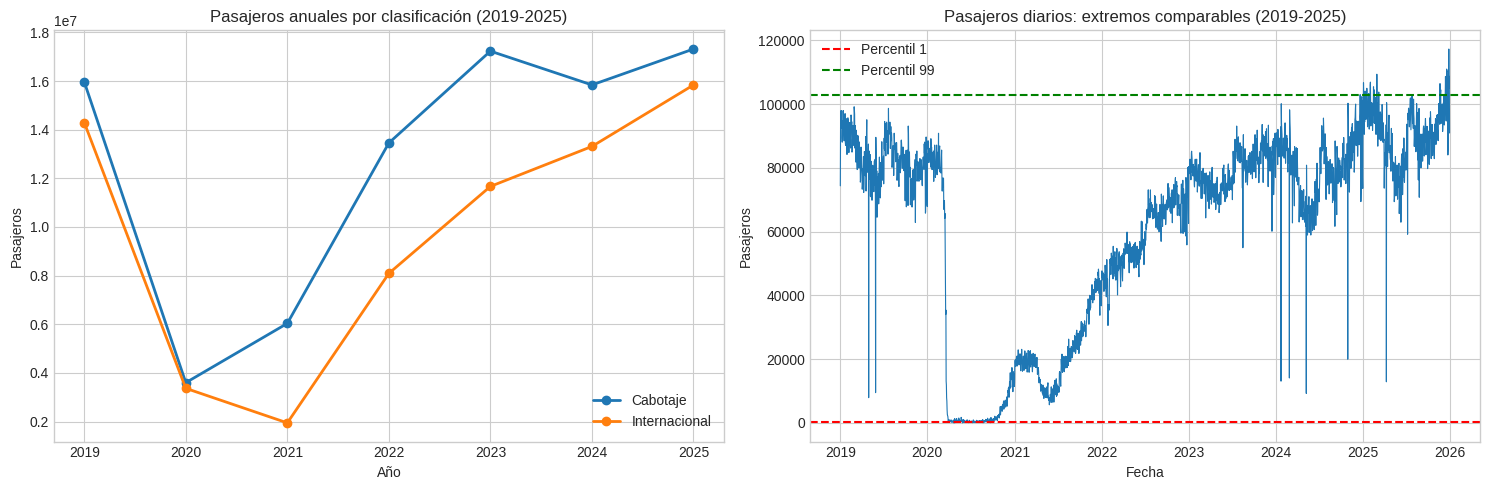

En 2020 la cantidad de pasajeros cayó un 76.97% respecto de 2019. En 2024, el mínimo diario fue de 9,265 pasajeros el 2024-05-09, mientras que el máximo fue de 102,988 pasajeros el 2024-12-21.


In [10]:
conectividad_anual = conectividad[conectividad['anio'].between(2019, 2025)].copy()
pasajeros_anuales = conectividad_anual.groupby(['anio', 'Clasificacion'])['Pasajeros'].sum().reset_index()

pasajeros_diarios = conectividad.groupby(['fecha', 'Clasificacion'])['Pasajeros'].sum().reset_index()
pasajeros_diarios_total = conectividad.groupby('fecha')['Pasajeros'].sum().reset_index()
pasajeros_diarios_total['anio'] = pasajeros_diarios_total['fecha'].dt.year

# Para detectar extremos comparables se excluye 2026 porque es un año parcial.
pasajeros_diarios_completo = pasajeros_diarios_total[pasajeros_diarios_total['anio'].between(2019, 2025)].copy()
q01 = pasajeros_diarios_completo['Pasajeros'].quantile(0.01)
q99 = pasajeros_diarios_completo['Pasajeros'].quantile(0.99)
atipicos_bajos = pasajeros_diarios_completo[pasajeros_diarios_completo['Pasajeros'] <= q01].sort_values('Pasajeros').head(10)
atipicos_altos = pasajeros_diarios_completo[pasajeros_diarios_completo['Pasajeros'] >= q99].sort_values('Pasajeros', ascending=False).head(10)

# Revisión puntual de 2024, mencionada en la discusión de clase.
pasajeros_2024_diarios = pasajeros_diarios_total[pasajeros_diarios_total['anio'] == 2024].copy()
extremos_2024_bajos = pasajeros_2024_diarios.sort_values('Pasajeros').head(5)
extremos_2024_altos = pasajeros_2024_diarios.sort_values('Pasajeros', ascending=False).head(5)

print('Pasajeros anuales por clasificación')
display(pasajeros_anuales)
print('Días con pasajeros muy bajos, excluyendo 2026 parcial')
display(atipicos_bajos[['fecha', 'Pasajeros']])
print('Días con pasajeros muy altos, excluyendo 2026 parcial')
display(atipicos_altos[['fecha', 'Pasajeros']])


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for clasificacion, datos in pasajeros_anuales.groupby('Clasificacion'):
    axes[0].plot(datos['anio'], datos['Pasajeros'], marker='o', linewidth=2, label=clasificacion)
axes[0].set_title('Pasajeros anuales por clasificación (2019-2025)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Pasajeros')
axes[0].legend()

axes[1].plot(pasajeros_diarios_completo['fecha'], pasajeros_diarios_completo['Pasajeros'], linewidth=0.8)
axes[1].axhline(q01, color='red', linestyle='--', label='Percentil 1')
axes[1].axhline(q99, color='green', linestyle='--', label='Percentil 99')
axes[1].set_title('Pasajeros diarios: extremos comparables (2019-2025)')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Pasajeros')
axes[1].legend()
plt.tight_layout()
plt.show()

pasajeros_2019 = pasajeros_anuales.loc[pasajeros_anuales['anio'] == 2019, 'Pasajeros'].sum()
pasajeros_2020 = pasajeros_anuales.loc[pasajeros_anuales['anio'] == 2020, 'Pasajeros'].sum()
caida_2020 = (1 - pasajeros_2020 / pasajeros_2019) * 100
max_2024 = extremos_2024_altos.iloc[0]
min_2024 = extremos_2024_bajos.iloc[0]

print(
    f"En 2020 la cantidad de pasajeros cayó un {caida_2020:.2f}% respecto de 2019. "
    f"En 2024, el mínimo diario fue de {min_2024['Pasajeros']:,.0f} pasajeros "
    f"el {min_2024['fecha'].date()}, mientras que el máximo fue de "
    f"{max_2024['Pasajeros']:,.0f} pasajeros el {max_2024['fecha'].date()}."
)

### Interpretación de los valores atípicos

La comparación anual muestra una caída del **76,97%** en la cantidad de pasajeros entre 2019 y 2020. En este caso, el valor atípico tiene una explicación vinculada con el contexto: las restricciones de movilidad aplicadas durante la pandemia redujeron considerablemente la actividad aérea.

En 2024, el menor valor diario se registró el **9 de mayo**, con **9.265 pasajeros**. El máximo de 2024 ocurrió el **21 de diciembre**, con **102.988 pasajeros**. A diferencia del mínimo, este valor forma parte de varios días consecutivos de demanda elevada: entre el 19 y el 23 de diciembre se registraron aproximadamente entre **94.819 y 102.988 pasajeros diarios**, período que coincide con las fiestas de fin de año. 

La caída de 2020 aporta información sobre el impacto de la pandemia; el mínimo del 9 de mayo de 2024 requiere cautela por su posible problema de calidad; y el máximo del 21 de diciembre representa una demanda alta sostenida durante varios días.

# ¿Cuál es el comportamiento general de las demoras?

count    336687.000000
mean         19.236591
std          44.550427
min        -179.000000
25%          -2.000000
50%          10.000000
75%          25.000000
90%          56.000000
95%          96.000000
max         360.000000
Name: delta_minutos, dtype: float64

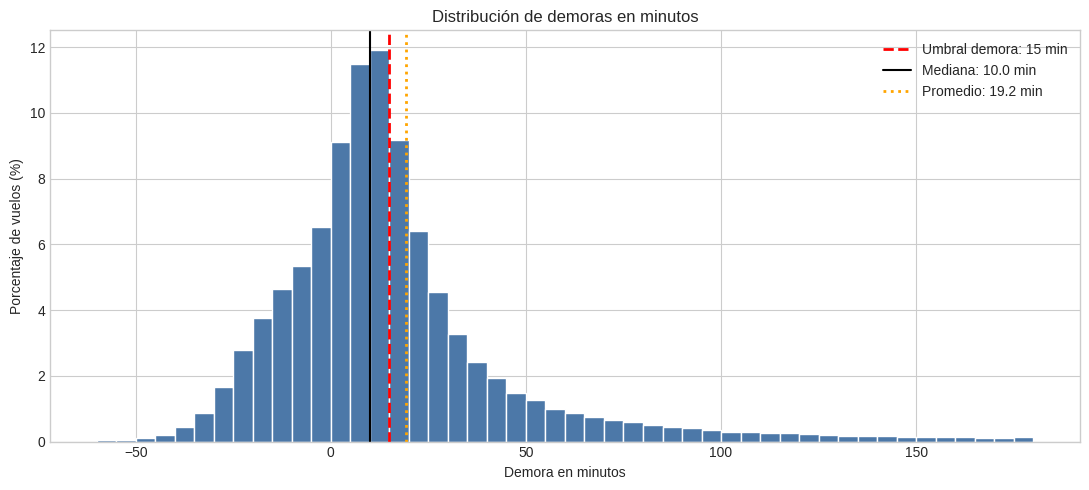

La demora promedio es de 19.24 minutos, mientras que la mediana es de 10.00 minutos. El 38.49% de los vuelos supera el umbral de 15 minutos definido para este análisis.


In [11]:
resumen_demoras = failbondi_limpio['delta_minutos'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
media_demora = failbondi_limpio['delta_minutos'].mean()
mediana_demora = failbondi_limpio['delta_minutos'].median()
porcentaje_demora_15 = failbondi_limpio['demorado_15m'].mean() * 100
porcentaje_adelanto_5 = failbondi_limpio['adelantado_5m'].mean() * 100
hora_mas_vuelos_failbondi = failbondi_limpio['hora'].mode().iloc[0]

display(resumen_demoras)

rango_visual = (-60, 180)
demoras = failbondi_limpio['delta_minutos'].dropna()
demoras_grafico = demoras[demoras.between(*rango_visual)]
pesos = np.ones(len(demoras_grafico)) / len(demoras) * 100

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(
    demoras_grafico,
    bins=np.arange(rango_visual[0], rango_visual[1] + 5, 5),
    weights=pesos,
    color='#4c78a8',
    edgecolor='white',
)
ax.axvline(15, color='red', linestyle='--', linewidth=2, label='Umbral demora: 15 min')
ax.axvline(mediana_demora, color='black', linewidth=1.5, label=f'Mediana: {mediana_demora:.1f} min')
ax.axvline(media_demora, color='orange', linestyle=':', linewidth=2, label=f'Promedio: {media_demora:.1f} min')
ax.set_title('Distribución de demoras en minutos')
ax.set_xlabel('Demora en minutos')
ax.set_ylabel('Porcentaje de vuelos (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"La demora promedio es de {media_demora:.2f} minutos, mientras que "
    f"la mediana es de {mediana_demora:.2f} minutos. "
    f"El {porcentaje_demora_15:.2f}% de los vuelos supera el umbral "
    f"de 15 minutos definido para este análisis."
)

### Interpretación de las demoras

La demora media es de **19,24 minutos**, mientras que la mediana es de **10 minutos**. La mediana indica que la mitad de los vuelos presenta una diferencia inferior a 10 minutos y la otra mitad una diferencia superior.

La media es mayor que la mediana porque existen vuelos con demoras considerablemente altas que desplazan el promedio hacia arriba. Esto muestra que la distribución no es simétrica, sino que presenta una cola hacia los valores elevados. Por eso, la mediana describe mejor una operación habitual, mientras que la media también refleja el efecto de las demoras extremas.

El **38,49%** de los vuelos supera los 15 minutos de demora. Esto significa que aproximadamente 38 de cada 100 vuelos analizados presentan una demora considerada relevante según el criterio definido.

En términos operativos, esta proporción justifica concentrar medidas de mejora en las partidas, los viernes y las franjas horarias de mayor demora. Entre las posibles decisiones se encuentran reforzar los procesos previos al despegue, revisar la asignación de personal y mejorar la coordinación durante los momentos de mayor riesgo.

# ¿Las demoras cambian según tipo de movimiento y aerolínea?

Demora por tipo de movimiento


,tipo_movimiento,vuelos,prob_demora_15m,demora_promedio_min,demora_mediana_min
0,Arribo,109669,19.934530,4.437507,-7.0
1,Partida,227018,47.449101,26.385806,15.0


Top aerolíneas por probabilidad de demora, con al menos 100 vuelos


,aerolinea,vuelos,prob_demora_15m,demora_promedio_min,demora_mediana_min
14,BOLIVIANA DE AVIACION,1292,64.473684,43.496130,28.5
5,AIR FRANCE,751,61.784288,25.366178,20.0
21,FLYBONDI,39246,58.242878,45.838277,21.0
12,AVIANCA ECUADOR,559,52.951699,22.694097,17.0
20,ETHIOPIAN AIRLINES,765,52.810458,35.679739,18.0
18,DHL AERO EXPRESO,672,51.339286,18.523810,16.0
9,ARAJET,1586,50.063052,28.600883,16.0
28,KLM,1505,46.777409,18.134884,14.0
17,DELTA AIR LINES,1365,46.739927,20.832967,15.0
10,AVIANCA,3746,46.502936,18.798185,14.0


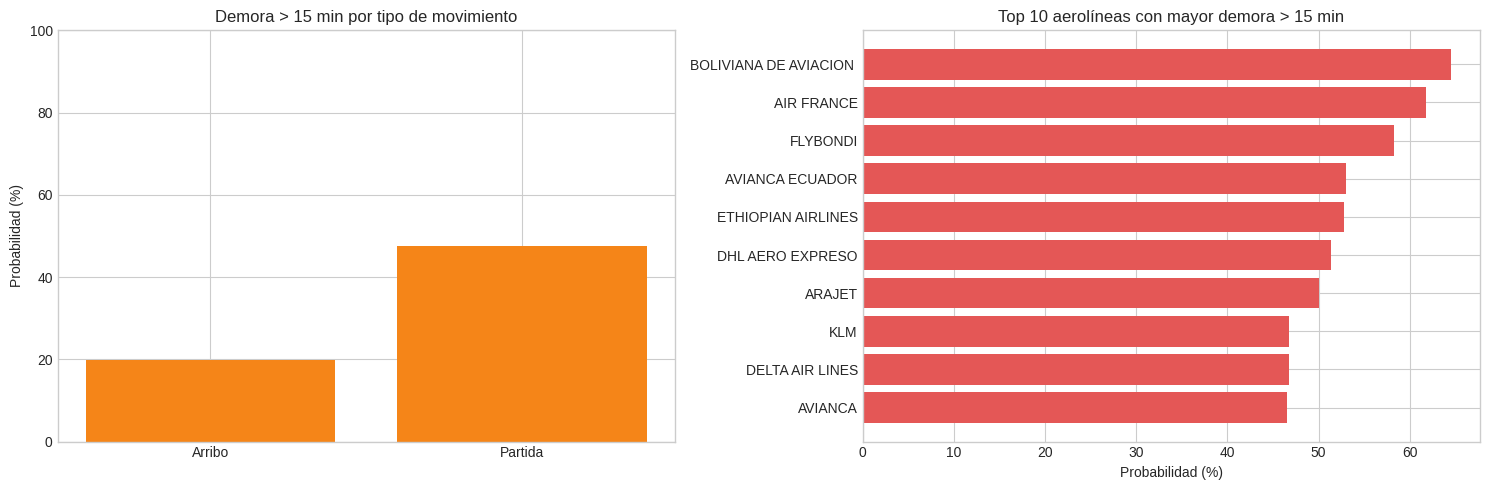

Conclusión: las partidas tienen mayor probabilidad de demora (47.45%) que los arribos (19.93%). Entre aerolíneas con al menos 100 vuelos, la mayor probabilidad observada corresponde a BOLIVIANA DE AVIACION  (64.47%).


In [12]:
prob_demora_por_movimiento = failbondi_limpio.groupby('tipo_movimiento').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
    demora_mediana_min=('delta_minutos', 'median'),
).reset_index()
prob_demora_por_movimiento['prob_demora_15m'] *= 100

min_vuelos_aerolinea = 100
prob_demora_por_aerolinea = failbondi_limpio.groupby('aerolinea').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
    demora_mediana_min=('delta_minutos', 'median'),
).query('vuelos >= @min_vuelos_aerolinea').reset_index()
prob_demora_por_aerolinea['prob_demora_15m'] *= 100
top_demora_aerolinea = prob_demora_por_aerolinea.sort_values('prob_demora_15m', ascending=False).head(10)

print('Demora por tipo de movimiento')
display(prob_demora_por_movimiento)
print('Top aerolíneas por probabilidad de demora, con al menos 100 vuelos')
display(top_demora_aerolinea)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(prob_demora_por_movimiento['tipo_movimiento'], prob_demora_por_movimiento['prob_demora_15m'], color='#f58518')
axes[0].set_title('Demora > 15 min por tipo de movimiento')
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_ylim(0, 100)

datos_aero = top_demora_aerolinea.sort_values('prob_demora_15m')
axes[1].barh(datos_aero['aerolinea'], datos_aero['prob_demora_15m'], color='#e45756')
axes[1].set_title('Top 10 aerolíneas con mayor demora > 15 min')
axes[1].set_xlabel('Probabilidad (%)')
plt.tight_layout()
plt.show()

partidas = prob_demora_por_movimiento.loc[prob_demora_por_movimiento['tipo_movimiento'] == 'Partida', 'prob_demora_15m'].iloc[0]
arribos = prob_demora_por_movimiento.loc[prob_demora_por_movimiento['tipo_movimiento'] == 'Arribo', 'prob_demora_15m'].iloc[0]
aerolinea_top = top_demora_aerolinea.iloc[0]
print(
    f"Conclusión: las partidas tienen mayor probabilidad de demora ({partidas:.2f}%) que los arribos ({arribos:.2f}%). "
    f"Entre aerolíneas con al menos {min_vuelos_aerolinea} vuelos, la mayor probabilidad observada corresponde a {aerolinea_top['aerolinea']} "
    f"({aerolinea_top['prob_demora_15m']:.2f}%)."
)

## Probabilidad total de demora según el tipo de movimiento

Se considera como demora relevante que un vuelo supere los 15 minutos.

Definimos los eventos:

- \(D\): el vuelo tiene una demora mayor a 15 minutos.
- \(P\): el movimiento es una partida.
- \(A\): el movimiento es un arribo.

La probabilidad de demora cambia según el tipo de movimiento:

- \(P(D \mid P)\): probabilidad de demora dado que es una partida.
- \(P(D \mid A)\): probabilidad de demora dado que es un arribo.

Como todo movimiento analizado es una partida o un arribo, ambos grupos forman una partición del conjunto de vuelos. Por lo tanto, se puede aplicar el teorema de la probabilidad total:

\[
P(D) = P(D \mid P)\cdot P(P) + P(D \mid A)\cdot P(A)
\]

La pregunta que se busca responder es:

> Si se selecciona un vuelo al azar, ¿cuál es la probabilidad total de que tenga más de 15 minutos de demora, considerando la proporción de partidas y arribos?

In [13]:
total_vuelos = len(failbondi_limpio)
es_partida = failbondi_limpio['tipo_movimiento'] == 'Partida'
es_arribo = failbondi_limpio['tipo_movimiento'] == 'Arribo'
prob_partida = es_partida.mean()
prob_arribo = es_arribo.mean()
prob_demora_dada_partida = (
    failbondi_limpio.loc[es_partida, 'demorado_15m'].mean()
)
prob_demora_dado_arribo = (
    failbondi_limpio.loc[es_arribo, 'demorado_15m'].mean()
)
prob_demora_total = (
    prob_demora_dada_partida * prob_partida
    + prob_demora_dado_arribo * prob_arribo
)
prob_demora_empirica = failbondi_limpio['demorado_15m'].mean()

resumen_probabilidad_total = pd.DataFrame({
    'Concepto': [
        'P(Partida)',
        'P(Arribo)',
        'P(Demora | Partida)',
        'P(Demora | Arribo)',
        'P(Demora) por probabilidad total',
        'P(Demora) observada directamente'
    ],
    'Probabilidad': [
        prob_partida,
        prob_arribo,
        prob_demora_dada_partida,
        prob_demora_dado_arribo,
        prob_demora_total,
        prob_demora_empirica
    ]
})

resumen_probabilidad_total['Porcentaje'] = (
    resumen_probabilidad_total['Probabilidad'] * 100
)

display(resumen_probabilidad_total.round(4))

print(
    f"La probabilidad total de que un vuelo tenga más de 15 minutos "
    f"de demora es {prob_demora_total * 100:.2f}%."
)

print(
    f"La frecuencia observada directamente es "
    f"{prob_demora_empirica * 100:.2f}%."
)

,Concepto,Probabilidad,Porcentaje
0,P(Partida),0.6743,67.4270
1,P(Arribo),0.3257,32.5730
2,P(Demora | Partida),0.4745,47.4491
3,P(Demora | Arribo),0.1993,19.9345
4,P(Demora) por probabilidad total,0.3849,38.4868
5,P(Demora) observada directamente,0.3849,38.4868


La probabilidad total de que un vuelo tenga más de 15 minutos de demora es 38.49%.
La frecuencia observada directamente es 38.49%.


### Interpretación

La probabilidad total de que un vuelo tenga más de 15 minutos de demora es aproximadamente **38,49%**.

Este resultado combina:

- La probabilidad de demora de las partidas, aproximadamente **47,45%**.
- La probabilidad de demora de los arribos, aproximadamente **19,93%**.
- La proporción que representa cada tipo de movimiento dentro del dataset.

El resultado coincide con la frecuencia general de demoras observada directamente en los datos. Esto verifica que la aplicación del teorema de la probabilidad total es correcta.

La probabilidad general se encuentra más cerca de la correspondiente a las partidas porque estas representan una proporción mayor de los movimientos analizados. En términos operativos, el resultado refuerza la recomendación de concentrar las medidas de mejora en los procesos previos a la salida de los vuelos.

# ¿Las demoras varían según hora del día y día de semana?

Demoras por hora


,hora,vuelos,prob_demora_15m,demora_promedio_min
0,0,5326,33.683815,17.571724
1,1,5030,33.081511,12.006362
2,2,4881,38.373284,18.175374
3,3,4323,27.411520,11.996068
4,4,6650,22.796992,9.566617
5,5,11706,29.856484,12.858876
6,6,12212,37.381264,18.206109
7,7,19026,34.568485,14.785872
8,8,16847,35.917374,15.544963
9,9,17299,34.059772,14.359501


Demoras por día


,dia_semana,vuelos,prob_demora_15m,demora_promedio_min
0,Lunes,49822,39.930151,19.988860
1,Martes,46772,36.526127,17.848927
2,Miércoles,46073,38.070019,18.397022
3,Jueves,47780,39.133529,19.411448
4,Viernes,49376,41.542450,21.846828
5,Sábado,47621,37.397367,18.609689
6,Domingo,49243,36.640741,18.398331


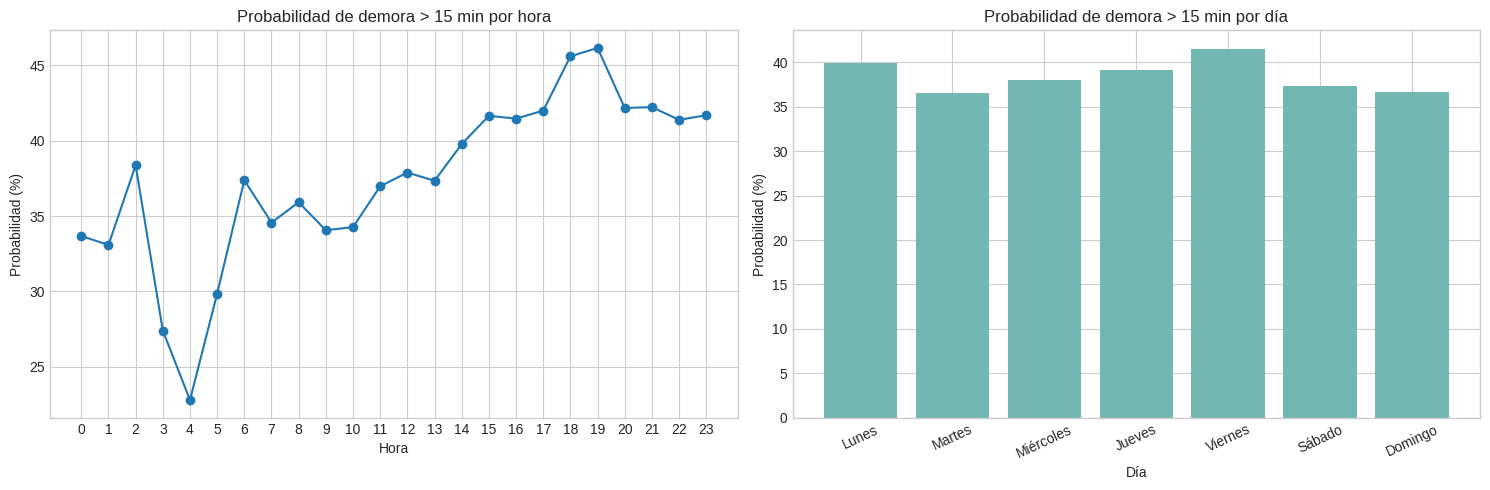

Conclusión: la mayor probabilidad de demora por hora aparece a las 19:00 (46.15%). Por día de semana, el peor valor se observa el Viernes (41.54%).


In [14]:
demora_por_hora = failbondi_limpio.groupby('hora').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
).reset_index()
demora_por_hora['prob_demora_15m'] *= 100

demora_por_dia = failbondi_limpio.groupby('dia_semana').agg(
    vuelos=('flight_id', 'count'),
    prob_demora_15m=('demorado_15m', 'mean'),
    demora_promedio_min=('delta_minutos', 'mean'),
).reindex(ORDEN_DIAS).reset_index()
demora_por_dia['prob_demora_15m'] *= 100

print('Demoras por hora')
display(demora_por_hora)
print('Demoras por día')
display(demora_por_dia)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(demora_por_hora['hora'], demora_por_hora['prob_demora_15m'], marker='o')
axes[0].set_title('Probabilidad de demora > 15 min por hora')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Probabilidad (%)')
axes[0].set_xticks(range(24))

axes[1].bar(demora_por_dia['dia_semana'], demora_por_dia['prob_demora_15m'], color='#72b7b2')
axes[1].set_title('Probabilidad de demora > 15 min por día')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Probabilidad (%)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

hora_peor = demora_por_hora.loc[demora_por_hora['prob_demora_15m'].idxmax()]
dia_peor = demora_por_dia.loc[demora_por_dia['prob_demora_15m'].idxmax()]
print(
    f"Conclusión: la mayor probabilidad de demora por hora aparece a las {int(hora_peor['hora'])}:00 "
    f"({hora_peor['prob_demora_15m']:.2f}%). Por día de semana, el peor valor se observa el {dia_peor['dia_semana']} "
    f"({dia_peor['prob_demora_15m']:.2f}%)."
)

# ¿El modelo de Poisson representa adecuadamente la cantidad diaria de vuelos demorados?

Se analiza si una distribución de Poisson permite estimar la cantidad diaria de vuelos con más de 15 minutos de demora.

En una distribución de Poisson, la media y la varianza deberían presentar valores similares. Por eso, además de calcular la probabilidad teórica, se comparan sus supuestos con la distribución observada.

,Indicador,Valor
0,Media diaria (λ),251.6117
1,Varianza diaria,7158.6660
2,Índice de dispersión,28.4513
3,Percentil 75,307.0000
4,Probabilidad teórica de superar 300,0.0014
5,Frecuencia empírica de superar 300,0.2777


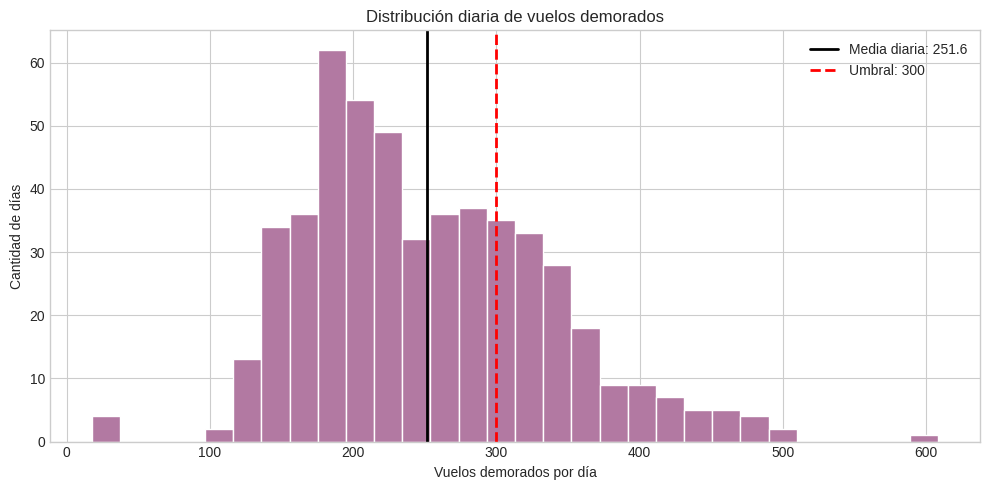

Media diaria (λ): 251.61
Varianza diaria: 7158.67
Índice de dispersión: 28.45
Percentil 75: 307
Probabilidad teórica de superar 300: 0.14%
Frecuencia empírica de superar 300: 27.77%


In [15]:
demoras_por_fecha = (
    failbondi_limpio
    .groupby('fecha')['demorado_15m']
    .sum()
)

lambda_diaria = demoras_por_fecha.mean()
varianza_diaria = demoras_por_fecha.var()
indice_dispersion = varianza_diaria / lambda_diaria

percentil_75_demoras = demoras_por_fecha.quantile(0.75)
umbral_poisson = 300

prob_poisson_mas_300 = poisson.sf(
    umbral_poisson,
    lambda_diaria
)

prob_empirica_mas_300 = (
    demoras_por_fecha > umbral_poisson
).mean()

resumen_poisson = pd.DataFrame({
    'Indicador': [
        'Media diaria (λ)',
        'Varianza diaria',
        'Índice de dispersión',
        'Percentil 75',
        'Probabilidad teórica de superar 300',
        'Frecuencia empírica de superar 300'
    ],
    'Valor': [
        lambda_diaria,
        varianza_diaria,
        indice_dispersion,
        percentil_75_demoras,
        prob_poisson_mas_300,
        prob_empirica_mas_300
    ]
})

display(resumen_poisson.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    demoras_por_fecha,
    bins=30,
    color='#b279a2',
    edgecolor='white'
)
ax.axvline(
    lambda_diaria,
    color='black',
    linewidth=2,
    label=f'Media diaria: {lambda_diaria:.1f}'
)
ax.axvline(
    umbral_poisson,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Umbral: {umbral_poisson}'
)
ax.set_title('Distribución diaria de vuelos demorados')
ax.set_xlabel('Vuelos demorados por día')
ax.set_ylabel('Cantidad de días')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Media diaria (λ): {lambda_diaria:.2f}")
print(f"Varianza diaria: {varianza_diaria:.2f}")
print(f"Índice de dispersión: {indice_dispersion:.2f}")
print(f"Percentil 75: {percentil_75_demoras:.0f}")
print(
    f"Probabilidad teórica de superar {umbral_poisson}: "
    f"{prob_poisson_mas_300 * 100:.2f}%"
)
print(
    f"Frecuencia empírica de superar {umbral_poisson}: "
    f"{prob_empirica_mas_300 * 100:.2f}%"
)

### Interpretación del modelo de Poisson nacional

El parámetro **λ = 251,61** representa la cantidad media de vuelos demorados que se registran por día. En otras palabras, durante un día típico del período analizado se observan aproximadamente 252 vuelos con más de 15 minutos de demora.

Se eligió como evento superar los **300 vuelos demorados** porque este valor se encuentra cerca del percentil 75, que es de **307 vuelos**. Por lo tanto, representa un día con una cantidad de demoras superior a la habitual y no un número elegido completamente al azar.

Sin embargo, la varianza diaria es de **7.158,67**, mientras que la media es de **251,61**. El cociente entre ambas es **28,45**, lo que muestra una sobredispersión muy elevada. Esto incumple el supuesto de Poisson según el cual la media y la varianza deberían ser aproximadamente iguales.

Como consecuencia, Poisson estima solamente un **0,14%** de probabilidad de superar 300 demoras, mientras que en los datos reales esto ocurre en el **27,77%** de los días. La diferencia demuestra que el modelo subestima fuertemente la variabilidad y no es adecuado para tomar decisiones en este caso.

Este resultado es importante porque muestra que no alcanza con aplicar una distribución matemática: también es necesario verificar si sus supuestos son compatibles con los datos observados.

# Conclusiones de la Parte I

El análisis nacional muestra que la demanda aérea no se distribuye uniformemente en el tiempo. Durante el período 2023-2025, la mayor demanda horaria de pasajeros equivalentes se registró a las **00:00 UTC**, mientras que la menor apareció a las **05:00 UTC**. A nivel semanal, el sábado presentó el mayor movimiento y el miércoles el menor, aunque la diferencia entre los días no fue demasiado amplia. En la comparación mensual, **diciembre** registró el promedio más alto y **junio** el más bajo. Estos resultados permiten identificar los momentos en los que puede ser necesario reforzar personal, capacidad aeroportuaria y servicios vinculados con el transporte.

El ranking de rutas muestra que **Ciudad de Buenos Aires-San Carlos de Bariloche** fue la ruta con mayor volumen de pasajeros dentro del conjunto analizado, con aproximadamente **7,42 millones de pasajeros**. También lideró el ranking de cabotaje, mientras que **Ezeiza-Madrid** encabezó las rutas internacionales. Este resultado indica que Bariloche no fue seleccionado arbitrariamente para la segunda parte: su importancia dentro del tráfico nacional y su actividad turística justifican estudiarlo con mayor detalle.

La ocupación media fue cercana al **81%** tanto en cabotaje como en vuelos internacionales, mientras que las medianas fueron de aproximadamente **85%**. Esto indica que ambos segmentos operaron habitualmente con una proporción elevada de asientos ocupados.

El análisis de las demoras mostró una media de **19,24 minutos** y una mediana de **10 minutos**. La diferencia entre ambas medidas indica que existe un grupo de demoras elevadas que desplaza el promedio hacia arriba. Además, el **38,49%** de los vuelos superó el umbral de 15 minutos definido para este trabajo. Las partidas presentaron una probabilidad de demora del **47,45%**, superior al **19,93%** observado en los arribos. Los valores más altos se concentraron alrededor de las **19:00** y los **viernes**, por lo que las acciones de mejora deberían enfocarse principalmente en los procesos previos a la salida y en esos momentos de mayor riesgo.

El modelo de Poisson nacional no representó adecuadamente la cantidad diaria de vuelos demorados. La media fue de **251,61 vuelos demorados por día**, pero la varianza alcanzó **7.158,67**, unas **28,45 veces la media**. Como consecuencia, el modelo estimó solamente un **0,14%** de probabilidad de superar 300 demoras, mientras que la frecuencia observada fue de **27,77%**. Esta diferencia demuestra que no alcanza con aplicar una distribución teórica: también es necesario comprobar que sus supuestos sean compatibles con los datos.

En conjunto, esta primera parte permitió identificar cuándo se concentra la demanda, qué rutas tienen mayor relevancia, cómo se comporta la ocupación y dónde aparecen los principales problemas de puntualidad. Dentro de estos resultados, el liderazgo de la ruta Buenos Aires-Bariloche y su relación con una actividad turística estacional justifican pasar de una descripción nacional a un análisis específico del aeropuerto de Bariloche, orientado a decisiones de planificación municipal, transporte terrestre y atención de pasajeros.

# PARTE II: San Carlos de Bariloche

## Objetivos y contexto del caso Bariloche
Como aplicación específica del análisis general, se estudia el aeropuerto de San Carlos de Bariloche. Ya que la ruta Buenos Aires-Bariloche es la de mayor volumen de pasajeros en el ranking nacional calculado dentro de los vuelos nacionales, ademas, presenta una fuerte actividad turística y variaciones estacionales, especialmente durante la temporada invernal. Por lo que es el mas interesante para analizar en detalle.
El análisis se plantea desde la perspectiva de un organismo de planificación turística municipal que necesita comprender la dinámica de los aterrizajes y despegues para anticipar períodos de mayor demanda y organizar los recursos vinculados con el aeropuerto y el transporte terrestre.
Debido al crecimiento sostenido del turismo, la infraestructura de la ciudad y el aeropuerto se ven exigidos, especialmente en las temporadas de invierno y verano.
El  organismo necesita entender la dinámica de los arribos y partidas para:
- Optimizar el transporte público y traslados: Ajustar las frecuencias de colectivos y servicios de traslados según el volumen de pasajeros por hora.
- Prever la saturación de la terminal: Identificar momentos críticos donde la cantidad de vuelos supere la capacidad operativa.
- Planificación estratégica: Utilizar modelos estadísticos para predecir flujos futuros basados en tendencias históricas.

# Preparación de los datos de Bariloche
Las librerias fueron cargadas al inicio del informe

In [16]:
# Filtrar únicamente los vuelos del aeropuerto de Bariloche (código IATA: BAR)
bariloche = anac_2023_2025[
    anac_2023_2025['Aeropuerto'] == 'BAR'
].copy()

## ¿Qué aeropuertos reciben más pasajeros durante 2023-2025?

In [17]:
pasajeros_por_aeropuerto = (
    anac_2023_2025[
        anac_2023_2025['Tipo de Movimiento'] == 'Aterrizaje'
    ]
    .groupby('Aeropuerto', as_index=False)['Pasajeros']
    .sum()
    .sort_values('Pasajeros', ascending=False)
    .head(10)
)

print(pasajeros_por_aeropuerto)

   Aeropuerto   Pasajeros
0         AER  24137206.0
18        EZE  16445138.0
5         CBA   4558234.0
2         BAR   3746563.0
13        DOZ   3664122.0
25        IGU   2472039.0
42        SAL   2198349.0
33        NEU   1802215.0
53        USU   1745226.0
16        ECA   1339734.0


# Análisis estadístico descriptivo para Bariloche

## ¿Cuál es la media y la mediana de pasajeros?

In [18]:
# Agrupar aterrizajes y despegues para obtener el movimiento diario de pasajeros en Bariloche
pasajeros_diarios = bariloche.groupby('Fecha UTC')['Pasajeros'].sum()

media_pasajeros   = pasajeros_diarios.mean()   
mediana_pasajeros = pasajeros_diarios.median() 
print(
    f"Media: Es el promedio aritmético de pasajeros por día. "
    f"Si la afluencia fuera constante durante todo el año "
    f"el destino debería esperar un movimiento de cercano a "        
    f"{media_pasajeros:.0f} pasajeros por día en el aeropuerto."   
)
print(
    f"La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan "
    f"menos de {mediana_pasajeros:.0f} pasajeros y el otro 50% llegan más."
)

Media: Es el promedio aritmético de pasajeros por día. Si la afluencia fuera constante durante todo el año el destino debería esperar un movimiento de cercano a 6873 pasajeros por día en el aeropuerto.
La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan menos de 6680 pasajeros y el otro 50% llegan más.


## ¿Cuál es su desvío estándar?

In [19]:
desvio_estandar    = pasajeros_diarios.std()
varianza_pasajeros = pasajeros_diarios.var()
print(f"Análisis de dispersión para Bariloche ")
print(f"Desvio estándar: {desvio_estandar:.0f}")
print(f"Varianza:        {varianza_pasajeros:.0f}")

porcentaje_desvio = desvio_estandar / media_pasajeros * 100

print(
    f"El desvío estándar es de {desvio_estandar:.0f} pasajeros, "
    f"equivalente al {porcentaje_desvio:.1f}% de la media diaria. "
    f"Esto indica cuánto suelen alejarse los movimientos diarios de pasajeros "
    f"del promedio de {media_pasajeros:.0f}. "
    f"No representa un aumento asegurado, sino la variabilidad observada entre los días."
)



Análisis de dispersión para Bariloche 
Desvio estándar: 2078
Varianza:        4317521
El desvío estándar es de 2078 pasajeros, equivalente al 30.2% de la media diaria. Esto indica cuánto suelen alejarse los movimientos diarios de pasajeros del promedio de 6873. No representa un aumento asegurado, sino la variabilidad observada entre los días.


## ¿Cuál es el movimiento diario promedio de pasajeros por mes?

 Número promedio de pasajeros diarios por mes 
    Mes  Media_Pasajeros_Diarios  Desvio_Estandar_Diario
0     1              7504.602151             1215.230459
1     2              6979.988235             1097.041123
2     3              5989.204301              772.573066
3     4              4813.356322              981.745799
4     5              4088.064516              879.351945
5     6              5481.833333             1130.073332
6     7              9841.086022             1813.728628
7     8              9958.301075             1354.574374
8     9              7842.166667             1331.087983
9    10              6404.602151              991.496214
10   11              6154.477778              972.280838
11   12              7253.258065             1077.373304


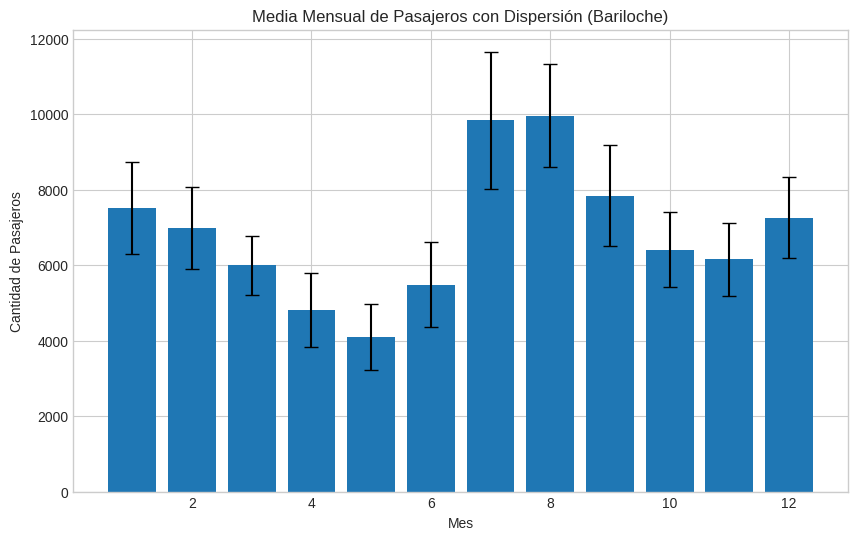

Agosto presenta el mayor movimiento diario promedio, con 9958 pasajeros registrados. Su desvío estándar es de 1355 pasajeros, por lo que un valor situado un desvío por encima de la media alcanza aproximadamente 11313 pasajeros.


In [20]:
#  Promedio de pasajeros diarios por mes en Bariloche 
pasajeros_por_dia = bariloche.groupby(bariloche['Fecha UTC'].dt.date)['Pasajeros'].sum().reset_index()
pasajeros_por_dia.columns = ['Fecha', 'Total_Pasajeros_Dia']

pasajeros_por_dia['Fecha'] = pd.to_datetime(pasajeros_por_dia['Fecha'])
pasajeros_por_dia['Mes']   = pasajeros_por_dia['Fecha'].dt.month

informe_municipal_diario = (
    pasajeros_por_dia
    .groupby('Mes')['Total_Pasajeros_Dia']
    .agg(['mean', 'std'])
    .reset_index()
)
informe_municipal_diario.columns = ['Mes', 'Media_Pasajeros_Diarios', 'Desvio_Estandar_Diario']

print(" Número promedio de pasajeros diarios por mes ")
print(informe_municipal_diario)

plt.figure(figsize=(10, 6))
plt.bar(
    informe_municipal_diario['Mes'],
    informe_municipal_diario['Media_Pasajeros_Diarios'],
    yerr=informe_municipal_diario['Desvio_Estandar_Diario'],
    capsize=5
)
plt.title('Media Mensual de Pasajeros con Dispersión (Bariloche)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pasajeros')
plt.show()
mes_max = informe_municipal_diario.loc[
    informe_municipal_diario['Media_Pasajeros_Diarios'].idxmax()
]
media_mes_max = mes_max['Media_Pasajeros_Diarios']
desvio_mes_max = mes_max['Desvio_Estandar_Diario']
limite_superior_mes_max = media_mes_max + desvio_mes_max

print(
    f"Agosto presenta el mayor movimiento diario promedio, con "
    f"{media_mes_max:.0f} pasajeros registrados. "
    f"Su desvío estándar es de {desvio_mes_max:.0f} pasajeros, "
    f"por lo que un valor situado un desvío por encima de la media "
    f"alcanza aproximadamente {limite_superior_mes_max:.0f} pasajeros."
)

## JULIO / AGOSTO vs MAYO: ¿Cómo varía el comportamiento?

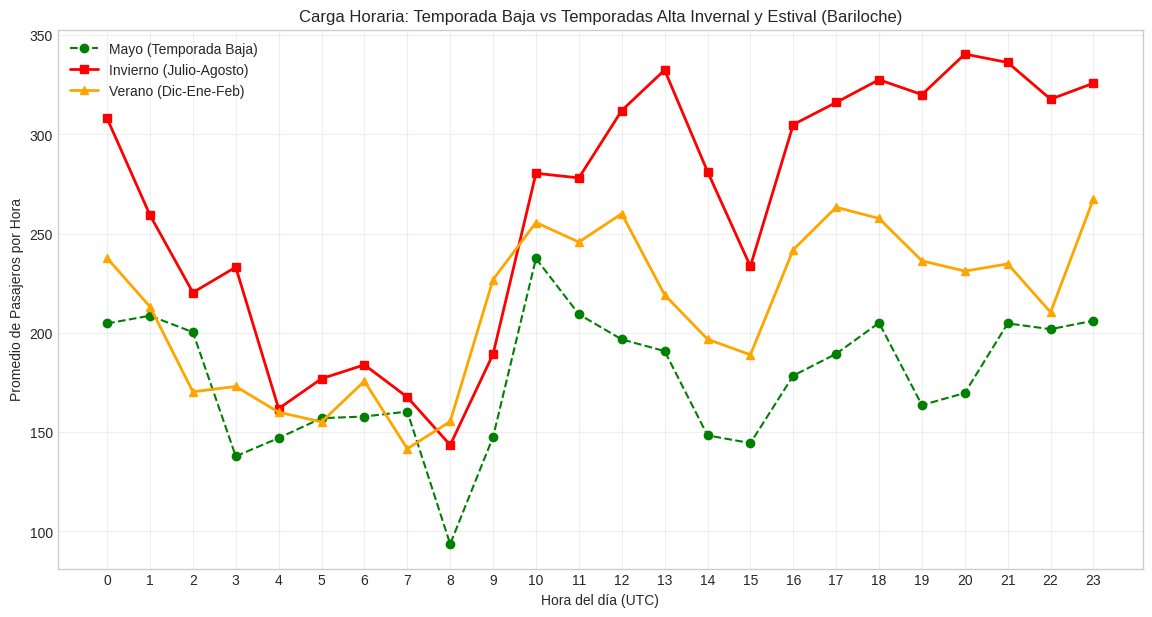

In [21]:
#  Análisis de carga horaria: temporada alta (agosto) vs. baja (mayo) 
anac_2023_2025['hora'] = pd.to_datetime(
    anac_2023_2025['Hora UTC'],
    format='%H:%M'
).dt.hour

filtro_base = (
    (anac_2023_2025['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac_2023_2025['Aeropuerto'] == 'BAR')
)
df_mayo = anac_2023_2025.loc[
    filtro_base &
    (anac_2023_2025['mes'] == 5)
]
df_invierno = anac_2023_2025.loc[
    filtro_base &
    (anac_2023_2025['mes'].isin([7, 8]))
]

df_verano = anac_2023_2025.loc[
    filtro_base &
    (anac_2023_2025['mes'].isin([12, 1, 2]))
]
def obtener_promedio_horario(df):
    pax_dia_hora = (
        df.groupby(['Fecha UTC', 'hora'])['Pasajeros']
        .sum()
        .reset_index()
    )

    return (
        pax_dia_hora
        .groupby('hora')['Pasajeros']
        .mean()
        .reset_index()
    )

promedio_mayo = obtener_promedio_horario(df_mayo)
promedio_invierno = obtener_promedio_horario(df_invierno)
promedio_verano = obtener_promedio_horario(df_verano)

tabla_comparativa = (
    promedio_mayo
    .merge(
        promedio_invierno,
        on='hora',
        suffixes=('_Mayo', '_Invierno')
    )
    .merge(
        promedio_verano,
        on='hora'
    )
)

tabla_comparativa.columns = [
    'Hora',
    'Promedio_Mayo',
    'Promedio_Invierno',
    'Promedio_Verano'
]
tabla_comparativa['Diferencia Mayo Invierno'] = (
    tabla_comparativa['Promedio_Invierno']
    - tabla_comparativa['Promedio_Mayo']
)

tabla_comparativa['Incremento_%'] = (
    tabla_comparativa['Diferencia Mayo Invierno']
    / tabla_comparativa['Promedio_Mayo']
    * 100
)

plt.figure(figsize=(14, 7))

plt.plot(
    promedio_mayo['hora'],
    promedio_mayo['Pasajeros'],
    label='Mayo (Temporada Baja)',
    color='green',
    marker='o',
    linestyle='--'
)

plt.plot(
    promedio_invierno['hora'],
    promedio_invierno['Pasajeros'],
    label='Invierno (Julio-Agosto)',
    color='red',
    marker='s',
    linewidth=2
)

plt.plot(
    promedio_verano['hora'],
    promedio_verano['Pasajeros'],
    label='Verano (Dic-Ene-Feb)',
    color='orange',
    marker='^',
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel('Hora del día (UTC)')
plt.ylabel('Promedio de Pasajeros por Hora')
plt.title('Carga Horaria: Temporada Baja vs Temporadas Alta Invernal y Estival (Bariloche)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La temporada invernal presenta la mayor demanda horaria de pasajeros. Durante julio y agosto, los aterrizajes alcanzan su máximo a las 20:00 UTC, con aproximadamente 340 pasajeros por hora, un 101% más que en mayo. La actividad se mantiene especialmente elevada entre las 12:00 y las 23:00 UTC.

Incluso en la franja de menor actividad, alrededor de las 08:00 UTC, el promedio invernal supera al de mayo en un 53%. Esto muestra que el aumento de la demanda no se limita a una hora puntual, sino que se extiende durante gran parte del día.

En verano, la demanda se ubica entre los niveles de mayo y del invierno, con un máximo aproximado de 268 pasajeros a las 18:00 UTC. Los resultados indican que la planificación de transporte terrestre, personal y servicios aeroportuarios debe reforzarse principalmente durante el invierno, especialmente desde el mediodía hasta el final de la jornada.

## En invierno, ¿Qué día de la semana recibe más pasajeros?

  dia_semana  Pasajeros
0      Lunes     4739.0
1     Martes     4698.0
2  Miércoles     4572.0
3     Jueves     5060.0
4    Viernes     4981.0
5     Sábado     5938.0
6    Domingo     4939.0


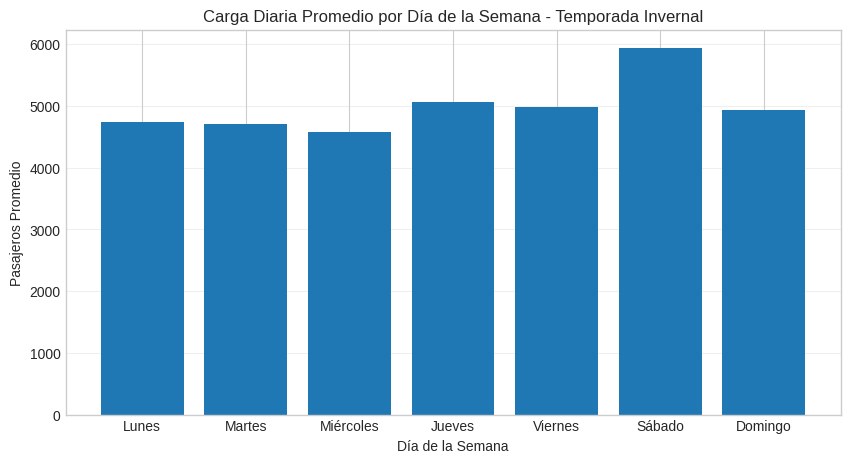

In [22]:
pax_diarios_invierno = (
    df_invierno
    .groupby('Fecha UTC')['Pasajeros']
    .sum()
    .reset_index()
)
pax_diarios_invierno['dia_semana'] = (
    pax_diarios_invierno['Fecha UTC']
    .dt.day_name()
)
orden_dias = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]
promedio_invierno_semanal = (
    pax_diarios_invierno
    .groupby('dia_semana')['Pasajeros']
    .mean()
    .reindex(orden_dias)
    .reset_index()
)
promedio_invierno_semanal['dia_semana'] = (
    promedio_invierno_semanal['dia_semana']
    .map(DIAS)
)
print(promedio_invierno_semanal.round(0))
plt.figure(figsize=(10, 5))

plt.bar(
    promedio_invierno_semanal['dia_semana'],
    promedio_invierno_semanal['Pasajeros']
)

plt.title('Carga Diaria Promedio por Día de la Semana - Temporada Invernal')
plt.ylabel('Pasajeros Promedio')
plt.xlabel('Día de la Semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

El análisis de la distribución semanal durante la temporada invernal evidencia una marcada concentración de pasajeros hacia el fin de semana. Los sábados constituyen el día de mayor demanda, con un promedio de 5.938 pasajeros, mientras que los miércoles registran el menor volumen, con 4.572 pasajeros. La diferencia entre ambos extremos alcanza aproximadamente 1.366 pasajeros diarios, lo que representa una variación cercana al 30%. Asimismo, se observa un incremento gradual de la actividad a partir del jueves, alcanzando su máximo durante el sábado. 

## Modelo normal: aterrizajes diarios durante agosto

Suponiendo que la cantidad diaria de pasajeros que aterrizan en Bariloche durante agosto puede aproximarse mediante una distribución normal, ¿cuál es la probabilidad de que la demanda diaria se encuentre dentro de un desvío estándar respecto de la media?

¿Por qué se analiza agosto? Agosto fue seleccionado porque el análisis descriptivo previo lo identifica como el mes con mayor demanda promedio en el aeropuerto de Bariloche. Además, corresponde a la temporada invernal, uno de los períodos turísticos más importantes para la ciudad.

No se utilizan todos los meses juntos porque la demanda presenta una marcada estacionalidad. Mezclar temporada alta y temporada baja produciría una población heterogénea, cuya media y desvío estándar podrían no representar correctamente ningún período particular.

En este análisis se consideran únicamente los **aterrizajes**, ya que el objetivo es estudiar la cantidad de pasajeros que efectivamente llegan al destino. Esta información puede utilizarse para planificar transporte terrestre, personal, atención aeroportuaria y servicios turísticos.

Se emplea el intervalo comprendido entre la media menos un desvío estándar y la media más un desvío estándar. En una distribución normal teórica, aproximadamente el 68,27% de las observaciones debería encontrarse dentro de ese intervalo. Este resultado se comparará con la frecuencia observada en los datos reales.

,Indicador,Valor
0,Cantidad de días analizados,93.0000
1,Media diaria,4846.8817
2,Desvío estándar,714.7042
3,Límite inferior,4132.1776
4,Límite superior,5561.5859
5,Probabilidad normal,0.6827
6,Frecuencia empírica,0.6667


Días analizados: 93
Media diaria: 4847 pasajeros
Desvío estándar: 715 pasajeros
Intervalo analizado: entre 4132 y 5562 pasajeros
Probabilidad según el modelo normal: 68.27%
Frecuencia observada en los datos reales: 66.67%


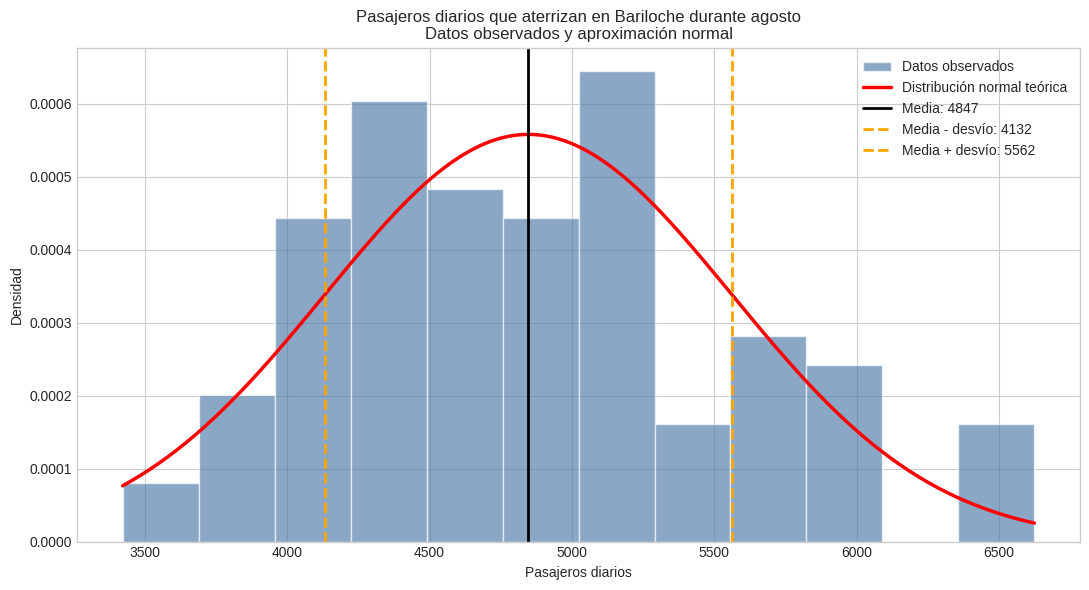

In [23]:
aterrizajes_agosto = anac_2023_2025[
    (anac_2023_2025['Aeropuerto'] == 'BAR') &
    (anac_2023_2025['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac_2023_2025['mes'] == 8)
].copy()

# Total de pasajeros que aterrizaron en Bariloche en cada fecha
pasajeros_diarios_agosto = (
    aterrizajes_agosto
    .groupby('Fecha UTC')['Pasajeros']
    .sum()
    .sort_index()
)

# Parámetros estimados a partir de los datos
media_agosto = pasajeros_diarios_agosto.mean()
desvio_agosto = pasajeros_diarios_agosto.std()

# Intervalo de un desvío estándar alrededor de la media
limite_inferior = media_agosto - desvio_agosto
limite_superior = media_agosto + desvio_agosto

# Probabilidad según el modelo normal
probabilidad_normal = (
    norm.cdf(limite_superior, loc=media_agosto, scale=desvio_agosto)
    - norm.cdf(limite_inferior, loc=media_agosto, scale=desvio_agosto)
)

# Frecuencia observada realmente en el dataset
frecuencia_empirica = pasajeros_diarios_agosto.between(
    limite_inferior,
    limite_superior
).mean()

resumen_normal = pd.DataFrame({
    'Indicador': [
        'Cantidad de días analizados',
        'Media diaria',
        'Desvío estándar',
        'Límite inferior',
        'Límite superior',
        'Probabilidad normal',
        'Frecuencia empírica'
    ],
    'Valor': [
        len(pasajeros_diarios_agosto),
        media_agosto,
        desvio_agosto,
        limite_inferior,
        limite_superior,
        probabilidad_normal,
        frecuencia_empirica
    ]
})

display(resumen_normal.round(4))

print(f"Días analizados: {len(pasajeros_diarios_agosto)}")
print(f"Media diaria: {media_agosto:.0f} pasajeros")
print(f"Desvío estándar: {desvio_agosto:.0f} pasajeros")
print(
    f"Intervalo analizado: entre {limite_inferior:.0f} "
    f"y {limite_superior:.0f} pasajeros"
)
print(
    f"Probabilidad según el modelo normal: "
    f"{probabilidad_normal * 100:.2f}%"
)
print(
    f"Frecuencia observada en los datos reales: "
    f"{frecuencia_empirica * 100:.2f}%"
)

# Histograma de los datos reales con curva normal superpuesta
x = np.linspace(
    pasajeros_diarios_agosto.min(),
    pasajeros_diarios_agosto.max(),
    300
)

densidad_normal = norm.pdf(
    x,
    loc=media_agosto,
    scale=desvio_agosto
)

plt.figure(figsize=(11, 6))

plt.hist(
    pasajeros_diarios_agosto,
    bins=12,
    density=True,
    alpha=0.65,
    color='#4c78a8',
    edgecolor='white',
    label='Datos observados'
)

plt.plot(
    x,
    densidad_normal,
    color='red',
    linewidth=2.5,
    label='Distribución normal teórica'
)

plt.axvline(
    media_agosto,
    color='black',
    linewidth=2,
    label=f'Media: {media_agosto:.0f}'
)

plt.axvline(
    limite_inferior,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Media - desvío: {limite_inferior:.0f}'
)

plt.axvline(
    limite_superior,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Media + desvío: {limite_superior:.0f}'
)

plt.title(
    'Pasajeros diarios que aterrizan en Bariloche durante agosto\n'
    'Datos observados y aproximación normal'
)
plt.xlabel('Pasajeros diarios')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación del modelo normal

El modelo normal estima que el **68,27%** de los días de agosto debería registrar entre **4.132 y 5.562 pasajeros que aterrizan en Bariloche**. Este intervalo corresponde a la media diaria, de aproximadamente **4.847 pasajeros**, más o menos un desvío estándar de **715 pasajeros**.

En los datos observados, el **66,67%** de los días se encuentra dentro de ese intervalo. La diferencia respecto del modelo teórico es de solamente **1,60 puntos porcentuales**, por lo que la distribución normal puede considerarse una aproximación descriptiva razonable para este rango. Esto no demuestra que toda la demanda siga exactamente una distribución normal.

Desde el punto de vista operativo, el intervalo permite estimar un rango habitual de arribos diarios durante agosto. Los días que superen los **5.562 pasajeros** pueden considerarse jornadas de demanda especialmente alta, en las que podría ser necesario reforzar el transporte terrestre, el personal y los servicios turísticos.

## ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

- **Binomial:** ¿Cuál es la probabilidad de que, al seleccionar 10 movimientos al azar durante la temporada invernal, al menos 3 transporten más de 174 pasajeros?
- **Poisson:** ¿Cuál es la probabilidad de que, durante un día de la temporada invernal, se registren más de 10 movimientos de muy alta demanda?

In [24]:
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")
p_alta_demanda = (
    df_invierno['Pasajeros'] > umbral_alto
).mean()

print(f"p = {p_alta_demanda:.3f}")
n = 10
k_min = 3

prob_binomial_al_menos_3 = sum(
    comb(n, k) * (p_alta_demanda ** k) * ((1 - p_alta_demanda) ** (n - k))
    for k in range(k_min, n + 1)
)

print(
    f"Probabilidad de que al menos 3 de 10 movimientos "
    f"sean de muy alta demanda "
    f"Porcentaje: {prob_binomial_al_menos_3 * 100:.2f}%"
)

Umbral de muy alta demanda: 174 pasajeros
p = 0.244
Probabilidad de que al menos 3 de 10 movimientos sean de muy alta demanda Porcentaje: 45.75%


### Interpretación del modelo binomial

Se considera de muy alta demanda a un movimiento que transporta más de **174 pasajeros**. Este umbral corresponde al percentil 75 de la distribución invernal, por lo que aproximadamente el **24,4%** de los movimientos lo supera.

El modelo analiza un escenario de **10 movimientos seleccionados al azar**. Este número no surge del dataset, sino que se utiliza como un grupo operativo sencillo para interpretar la frecuencia de movimientos de alta demanda.

Preguntar por “al menos 3 de 10” significa calcular la probabilidad de que el **30% o más** de los movimientos seleccionados sea de muy alta demanda.

La probabilidad individual es `p = 0,244`, la cantidad esperada dentro de un grupo de 10 es 2.44.

Esto significa que se esperan, en promedio, entre 2 y 3 movimientos de muy alta demanda por cada grupo de 10. Por eso, obtener al menos 3 es un resultado cercano, aunque ligeramente superior, al valor esperado.

La probabilidad calculada es de **45,75%**. Es decir, en casi 46 de cada 100 grupos hipotéticos de 10 movimientos habría al menos 3 operaciones con más de 174 pasajeros.

Este resultado permite anticipar que los movimientos de muy alta demanda no son excepcionales durante el invierno. Aerolíneas, aeropuerto y servicios terrestres deberían prever capacidad suficiente para atender varios movimientos con una alta concentración de pasajeros.

In [25]:
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

movimientos_invierno = df_invierno.assign(
    es_muy_alta_demanda=(
        df_invierno['Pasajeros'] > umbral_alto
    ).astype(int)
)

altos_por_dia = (
    movimientos_invierno
    .groupby('Fecha UTC')['es_muy_alta_demanda']
    .sum()
)

lambda_poisson = altos_por_dia.mean()
varianza_altos_diarios = altos_por_dia.var()
indice_dispersion_altos = (
    varianza_altos_diarios / lambda_poisson
)

umbral_movimientos = 10

prob_mas_de_10 = poisson.sf(
    umbral_movimientos,
    lambda_poisson
)

frecuencia_empirica_mas_de_10 = (
    altos_por_dia > umbral_movimientos
).mean()

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")
print(f"Media diaria (λ): {lambda_poisson:.2f}")
print(f"Varianza diaria: {varianza_altos_diarios:.2f}")
print(f"Índice de dispersión: {indice_dispersion_altos:.2f}")
print(
    f"Probabilidad teórica de registrar más de "
    f"{umbral_movimientos} movimientos: "
    f"{prob_mas_de_10 * 100:.2f}%"
)
print(
    f"Frecuencia empírica observada: "
    f"{frecuencia_empirica_mas_de_10 * 100:.2f}%"
)

Umbral de muy alta demanda: 174 pasajeros
Media diaria (λ): 8.27
Varianza diaria: 11.23
Índice de dispersión: 1.36
Probabilidad teórica de registrar más de 10 movimientos: 21.22%
Frecuencia empírica observada: 18.28%


### Interpretación del modelo de Poisson

En este análisis, **λ = 8,27** representa la cantidad media diaria de movimientos de muy alta demanda durante la temporada invernal. Es decir, en un día de invierno se registran, en promedio, algo más de 8 movimientos con más de 174 pasajeros.

El evento analizado es que se produzcan **más de 10 movimientos** de esta categoría. Este valor representa un día por encima del promedio, porque supera en aproximadamente dos movimientos el valor esperado de 8,27.

El modelo de Poisson estima una probabilidad del **21,22%**. Esto significa que, según el modelo teórico, aproximadamente 21 de cada 100 días de invierno podrían registrar más de 10 movimientos de muy alta demanda.

La frecuencia observada realmente en el dataset es de **18,28%**. La diferencia con la estimación teórica es de **2,94 puntos porcentuales**, por lo que la aproximación resulta razonablemente cercana.

La media diaria es **8,27** y la varianza es **11,23**, con un índice de dispersión de aproximadamente **1,36**. La varianza es algo mayor que la media, por lo que existe una dispersión moderada, pero la diferencia es mucho menor que en el modelo nacional. Por eso Poisson puede utilizarse como una aproximación, aunque no representa perfectamente todos los días.

Desde el punto de vista operativo, una probabilidad cercana al 20% no es despreciable. El aeropuerto y los servicios terrestres deberían contemplar que aproximadamente uno de cada cinco días invernales puede superar los 10 movimientos de muy alta demanda.

## Parte predictiva: feriados largos y demanda en Bariloche

Aclaración: en esta sección predictiva se trabaja específicamente con los aterrizajes en el aeropuerto de Bariloche, ya que el objetivo es estimar la llegada de pasajeros al destino turístico. Por este motivo, los valores utilizados en el modelo pueden diferir de otros apartados del trabajo donde se consideran todos los movimientos aeroportuarios, incluyendo aterrizajes y despegues.

In [26]:

bariloche_aterrizajes = anac_2023_2025[
    (anac_2023_2025['Aeropuerto'] == 'BAR') &
    (anac_2023_2025['Tipo de Movimiento'] == 'Aterrizaje')
].copy()

datos_diarios = (
    bariloche_aterrizajes
    .groupby('Fecha UTC')
    .agg(
        pasajeros_totales=('Pasajeros', 'sum'),
        cantidad_vuelos=('Pasajeros', 'count'),
        pasajeros_promedio_por_vuelo=('Pasajeros', 'mean')
    )
    .reset_index()
)

datos_diarios['anio'] = datos_diarios['Fecha UTC'].dt.year
datos_diarios['mes'] = datos_diarios['Fecha UTC'].dt.month
datos_diarios['dia'] = datos_diarios['Fecha UTC'].dt.day
datos_diarios['dia_semana_num'] = datos_diarios['Fecha UTC'].dt.dayofweek

datos_diarios['es_fin_de_semana'] = datos_diarios['dia_semana_num'].isin([5, 6]).astype(int)

display(datos_diarios.head())

,Fecha UTC,pasajeros_totales,cantidad_vuelos,pasajeros_promedio_por_vuelo,anio,mes,dia,dia_semana_num,es_fin_de_semana
0,2023-01-01,2903.0,23,126.217391,2023,1,1,6,1
1,2023-01-02,3461.0,30,115.366667,2023,1,2,0,0
2,2023-01-03,3600.0,27,133.333333,2023,1,3,1,0
3,2023-01-04,4137.0,32,129.281250,2023,1,4,2,0
4,2023-01-05,3942.0,28,140.785714,2023,1,5,3,0


In [27]:
# # Lista de feriados en Argentina segun la web del gobierno nacional

feriados_largos = [
    # 2023
    ('2023-01-01', '2023-01-01'),  # Año Nuevo
    ('2023-02-18', '2023-02-21'),  # Carnaval
    ('2023-03-24', '2023-03-26'),  # Día de la Memoria
    ('2023-04-02', '2023-04-02'),  # Malvinas
    ('2023-04-06', '2023-04-09'),  # Jueves Santo + Viernes Santo + Semana Santa
    ('2023-04-29', '2023-05-01'),  # Día del Trabajador
    ('2023-05-25', '2023-05-28'),  # Revolución de Mayo + puente turístico
    ('2023-06-17', '2023-06-20'),  # Güemes + puente turístico + Belgrano
    ('2023-07-09', '2023-07-09'),  # Día de la Independencia
    ('2023-08-19', '2023-08-21'),  # San Martín trasladado
    ('2023-10-13', '2023-10-16'),  # Puente turístico + Diversidad Cultural trasladado
    ('2023-11-18', '2023-11-20'),  # Soberanía Nacional
    ('2023-12-08', '2023-12-10'),  # Inmaculada Concepción
    ('2023-12-23', '2023-12-25'),  # Navidad

    # 2024
    ('2024-01-01', '2024-01-01'),  # Año Nuevo
    ('2024-02-10', '2024-02-13'),  # Carnaval
    ('2024-03-24', '2024-03-24'),  # Día de la Memoria
    ('2024-03-28', '2024-04-02'),  # Semana Santa + puente turístico + Malvinas
    ('2024-05-01', '2024-05-01'),  # Día del Trabajador
    ('2024-05-25', '2024-05-26'),  # Revolución de Mayo
    ('2024-06-15', '2024-06-17'),  # Güemes
    ('2024-06-20', '2024-06-23'),  # Belgrano + puente turístico
    ('2024-07-09', '2024-07-09'),  # Día de la Independencia
    ('2024-08-17', '2024-08-18'),  # San Martín
    ('2024-10-11', '2024-10-13'),  # Puente turístico + Diversidad Cultural
    ('2024-11-16', '2024-11-18'),  # Soberanía Nacional
    ('2024-12-08', '2024-12-08'),  # Inmaculada Concepción
    ('2024-12-25', '2024-12-25'),  # Navidad

    # 2025
    ('2025-01-01', '2025-01-01'),  # Año Nuevo
    ('2025-03-01', '2025-03-04'),  # Carnaval
    ('2025-03-22', '2025-03-24'),  # Día de la Memoria
    ('2025-04-02', '2025-04-02'),  # Malvinas
    ('2025-04-17', '2025-04-20'),  # Jueves Santo + Viernes Santo + Semana Santa
    ('2025-05-01', '2025-05-04'),  # Día del Trabajador + puente turístico
    ('2025-05-25', '2025-05-25'),  # Revolución de Mayo
    ('2025-06-14', '2025-06-16'),  # Güemes trasladado
    ('2025-06-20', '2025-06-22'),  # Belgrano
    ('2025-07-09', '2025-07-09'),  # Día de la Independencia
    ('2025-08-15', '2025-08-17'),  # Puente turístico + San Martín
    ('2025-10-10', '2025-10-12'),  # Diversidad Cultural trasladado
    ('2025-11-21', '2025-11-24'),  # Puente turístico + Soberanía Nacional trasladado
    ('2025-12-06', '2025-12-08'),  # Inmaculada Concepción
    ('2025-12-25', '2025-12-25'),  # Navidad
]

# Función para identificar si una fecha pertenece a un feriado largo
def marcar_feriado_largo(fecha):
    for inicio, fin in feriados_largos:
        if pd.to_datetime(inicio) <= fecha <= pd.to_datetime(fin):
            return 1
    return 0

# Creamos la variable
datos_diarios['es_feriado_largo'] = datos_diarios['Fecha UTC'].apply(marcar_feriado_largo)
print("Cantidad de días marcados como feriado o fin de semana largo:")
print(datos_diarios['es_feriado_largo'].value_counts())

display(
    datos_diarios[datos_diarios['es_feriado_largo'] == 1]
    [['Fecha UTC', 'pasajeros_totales', 'cantidad_vuelos']]
    .head(20)
)

Cantidad de días marcados como feriado o fin de semana largo:
es_feriado_largo
0    980
1    113
Name: count, dtype: int64


,Fecha UTC,pasajeros_totales,cantidad_vuelos
0,2023-01-01,2903.0,23
48,2023-02-18,4103.0,29
49,2023-02-19,3858.0,26
50,2023-02-20,3095.0,20
51,2023-02-21,2611.0,32
82,2023-03-24,2781.0,23
83,2023-03-25,2661.0,28
84,2023-03-26,2839.0,29
91,2023-04-02,3244.0,26
95,2023-04-06,3267.0,27


La variable `es_feriado_largo` identifica fechas correspondientes a feriados nacionales, fines de semana largos y días no laborables con fines turísticos dentro del período analizado. Se incluyeron tanto períodos de varios días como feriados de un solo día, debido a que ambos pueden afectar la demanda turística y el movimiento de pasajeros hacia Bariloche.

In [28]:
comparacion_feriados = (
    datos_diarios
    .groupby('es_feriado_largo')
    .agg(
        dias_analizados=('Fecha UTC', 'count'),
        promedio_pasajeros=('pasajeros_totales', 'mean'),
        promedio_vuelos=('cantidad_vuelos', 'mean'),
        promedio_pasajeros_por_vuelo=('pasajeros_promedio_por_vuelo', 'mean')
    )
    .reset_index()
)

comparacion_feriados['tipo_dia'] = comparacion_feriados['es_feriado_largo'].map({
    0: 'Día normal',
    1: 'Feriado largo'
})

display(comparacion_feriados)

,es_feriado_largo,dias_analizados,promedio_pasajeros,promedio_vuelos,promedio_pasajeros_por_vuelo,tipo_dia
0,0,980,3435.130612,25.505102,135.697710,Día normal
1,1,113,3364.026549,25.008850,135.667937,Feriado largo


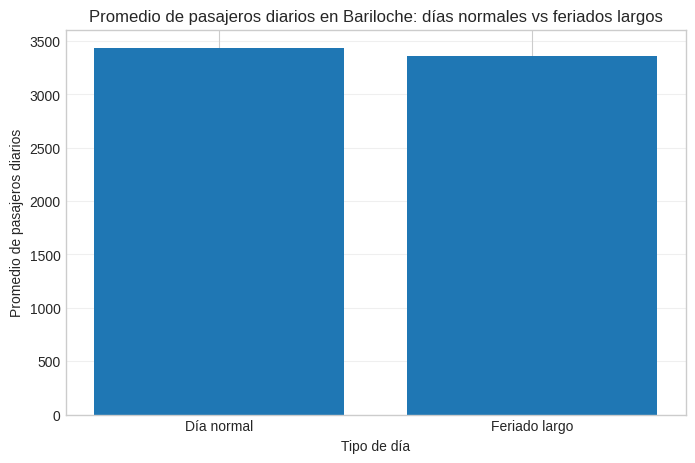

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_feriados['tipo_dia'],
    comparacion_feriados['promedio_pasajeros']
)

plt.title('Promedio de pasajeros diarios en Bariloche: días normales vs feriados largos')
plt.xlabel('Tipo de día')
plt.ylabel('Promedio de pasajeros diarios')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [30]:

X = datos_diarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo',
        'cantidad_vuelos'
    ]
]

y = datos_diarios['pasajeros_totales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo predictivo")
print(f"Error absoluto medio MAE: {mae:.2f} pasajeros")
print(f"R2 del modelo: {r2:.2f}")

Evaluación del modelo predictivo
Error absoluto medio MAE: 313.39 pasajeros
R2 del modelo: 0.86


,variable,importancia
4,cantidad_vuelos,0.810355
0,mes,0.147049
1,dia_semana_num,0.032328
3,es_feriado_largo,0.005529
2,es_fin_de_semana,0.004739


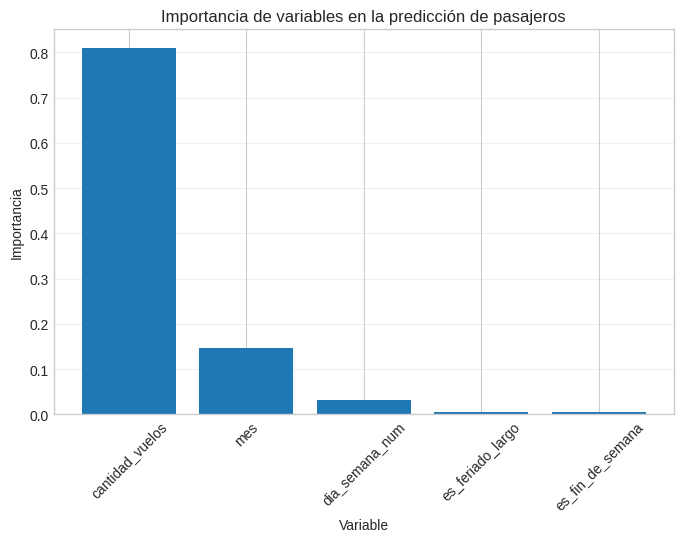

In [31]:
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancias)

plt.figure(figsize=(8, 5))

plt.bar(
    importancias['variable'],
    importancias['importancia']
)

plt.title('Importancia de variables en la predicción de pasajeros')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

## Ejemplos de predicciones para días específicos

In [32]:
# Comparación de dos escenarios idénticos salvo por la condición de feriado
escenarios_feriado = pd.DataFrame({
    'mes': [7, 7],
    'dia_semana_num': [5, 5],       # sábado
    'es_fin_de_semana': [1, 1],
    'es_feriado_largo': [0, 1],
    'cantidad_vuelos': [30, 30]
}, index=['Sábado normal', 'Sábado feriado'])

predicciones = modelo.predict(escenarios_feriado)

resultado_escenarios = pd.DataFrame({
    'Escenario': escenarios_feriado.index,
    'Pasajeros estimados': predicciones.round().astype(int)
})

diferencia = predicciones[1] - predicciones[0]
porcentaje = diferencia / predicciones[0] * 100

display(resultado_escenarios)

print(
    f"Diferencia estimada al cambiar únicamente la condición de feriado: "
    f"{diferencia:.0f} pasajeros ({porcentaje:.2f}%)."
)

,Escenario,Pasajeros estimados
0,Sábado normal,4674
1,Sábado feriado,4664


Diferencia estimada al cambiar únicamente la condición de feriado: -9 pasajeros (-0.20%).


### Interpretación de la comparación

Para aislar el efecto de la variable `es_feriado_largo`, se compararon dos escenarios con el mismo mes, día de la semana, condición de fin de semana y cantidad de vuelos. La única diferencia entre ellos es si la fecha pertenece o no a un feriado largo.

De esta manera, la diferencia estimada no se atribuye erróneamente a cambios en la cantidad de vuelos o en el día analizado. Sin embargo, debe interpretarse como la asociación aprendida por el modelo y no como una relación causal demostrada.

Para la parte predictiva se construyeron dos modelos que estiman la cantidad diaria de pasajeros que arriban al aeropuerto de Bariloche. Para ello se utilizaron variables temporales como el mes, el día de la semana, si corresponde a fin de semana y si pertenece a un feriado largo. También se incorporó la cantidad de vuelos diarios como indicador de actividad aeroportuaria.

La variable `es_feriado_largo` permite comparar los aterrizajes registrados en días normales y feriados largos. En el período 2023-2025, los días normales presentan un promedio de **3.435 pasajeros**, mientras que los feriados largos registran **3.364 pasajeros**.

Además, el **25,82%** de los días normales fue clasificado como de alta demanda, frente al **18,58%** de los feriados largos. Por lo tanto, en estos datos los feriados largos no presentan por sí solos un incremento de la demanda.

Este resultado indica que no conviene planificar recursos considerando únicamente los feriados. La estacionalidad mensual, el día de la semana y la cantidad de vuelos resultan variables más relevantes para anticipar la demanda.

### Interpretación del modelo con cantidad de vuelos

El primer modelo obtuvo un **MAE de 313,39 pasajeros** y un **R² de 0,86**. El MAE indica que las predicciones se alejan de los valores reales aproximadamente 313 pasajeros por día, en promedio. El R² indica que el modelo explica una parte importante de la variabilidad observada, pero no debe interpretarse como un porcentaje de exactitud.

La variable `cantidad_vuelos` concentra aproximadamente el **81,04%** de la importancia del modelo. Esto es esperable porque la cantidad diaria de pasajeros depende directamente del número de vuelos operados. Por lo tanto, el buen desempeño del modelo depende en gran medida de conocer previamente cuántos vuelos habrá.

La variable `es_feriado_largo` presenta una importancia considerablemente menor, su importancia es baja ya que los feriados no registraron mayor demanda promedio que los días normales. Esto coincide con la comparación descriptiva, en la que los feriados largos

In [33]:
# Modelo alternativo sin cantidad_vuelos
# Este modelo sirve para ver mejor el efecto de las variables de calendario,
# como mes, día de semana, fin de semana y feriado largo.

X_calendario = datos_diarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo'
    ]
]

y = datos_diarios['pasajeros_totales']

X_train, X_test, y_train, y_test = train_test_split(
    X_calendario,
    y,
    test_size=0.2,
    random_state=42
)

modelo_calendario = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_calendario.fit(X_train, y_train)

y_pred = modelo_calendario.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluación del modelo predictivo sin cantidad de vuelos")
print(f"Error absoluto medio MAE: {mae:.2f} pasajeros")
print(f"R2 del modelo: {r2:.2f}")

Evaluación del modelo predictivo sin cantidad de vuelos
Error absoluto medio MAE: 469.03 pasajeros
R2 del modelo: 0.69


,variable,importancia
0,mes,0.849998
1,dia_semana_num,0.110114
2,es_fin_de_semana,0.020229
3,es_feriado_largo,0.019658


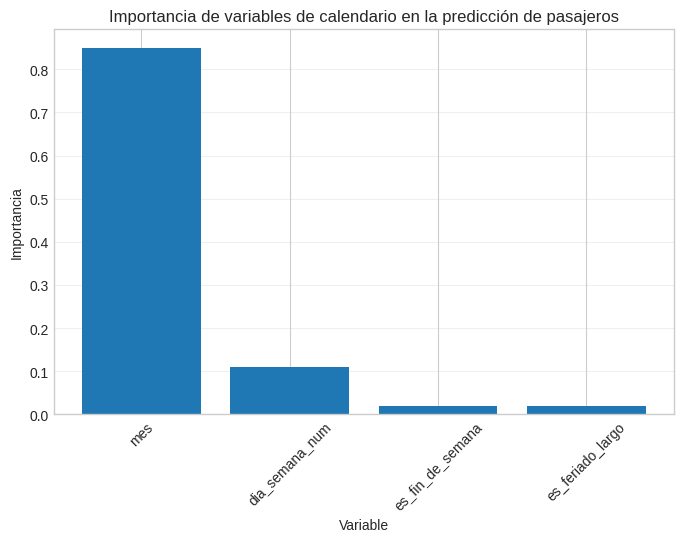

In [34]:
importancias_calendario = pd.DataFrame({
    'variable': X_calendario.columns,
    'importancia': modelo_calendario.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancias_calendario)

plt.figure(figsize=(8, 5))

plt.bar(
    importancias_calendario['variable'],
    importancias_calendario['importancia']
)

plt.title('Importancia de variables de calendario en la predicción de pasajeros')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

### Interpretación del modelo basado en el calendario

El segundo modelo excluye la cantidad de vuelos para analizar específicamente el aporte de las variables de calendario: mes, día de la semana, fin de semana y feriado largo.

Este modelo obtuvo un **MAE de 469,03 pasajeros** y un **R² de 0,69**. El MAE indica que las predicciones se alejan de los valores reales aproximadamente 469 pasajeros por día, en promedio. El R² indica que el modelo explica parte de la variabilidad observada, pero no representa un porcentaje de exactitud.

El **mes** concentra aproximadamente el **85,00%** de la importancia, seguido por el **día de la semana con 11,01%**, la condición de **fin de semana con 2,02%** y el **feriado largo con 1,97%**.

Estos resultados indican que la estacionalidad mensual es el principal factor de calendario para anticipar la demanda. Los feriados largos tienen una incidencia mucho menor y no deben utilizarse como único criterio para planificar recursos.

## Comparación entre valores reales y valores predichos

In [35]:

comparacion_predicciones = pd.DataFrame({
    'pasajeros_reales': y_test.values,
    'pasajeros_predichos': y_pred
})

comparacion_predicciones['diferencia'] = (
    comparacion_predicciones['pasajeros_reales'] - comparacion_predicciones['pasajeros_predichos']
)

display(comparacion_predicciones.head(10))

,pasajeros_reales,pasajeros_predichos,diferencia
0,2104.0,1967.358569,136.641431
1,2745.0,2181.105973,563.894027
2,2817.0,2981.013713,-164.013713
3,2604.0,2571.061095,32.938905
4,4904.0,4138.008956,765.991044
5,2735.0,2591.036158,143.963842
6,4335.0,3910.804667,424.195333
7,3504.0,3367.298639,136.701361
8,4027.0,3849.515654,177.484346
9,4200.0,4062.758449,137.241551


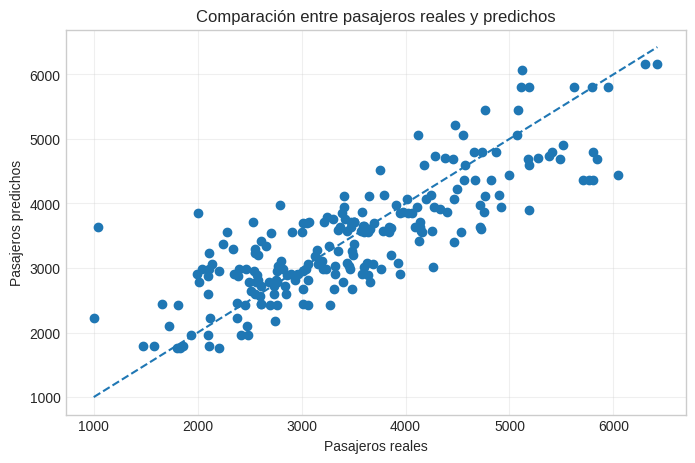

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    comparacion_predicciones['pasajeros_reales'],
    comparacion_predicciones['pasajeros_predichos']
)

# Línea de referencia: predicción perfecta
min_val = min(
    comparacion_predicciones['pasajeros_reales'].min(),
    comparacion_predicciones['pasajeros_predichos'].min()
)

max_val = max(
    comparacion_predicciones['pasajeros_reales'].max(),
    comparacion_predicciones['pasajeros_predichos'].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.title('Comparación entre pasajeros reales y predichos')
plt.xlabel('Pasajeros reales')
plt.ylabel('Pasajeros predichos')
plt.grid(alpha=0.3)

plt.show()

La línea diagonal representa una predicción perfecta. Los puntos cercanos a esa línea indican predicciones más precisas, mientras que los puntos alejados muestran una mayor diferencia entre el valor real y el valor estimado.

In [37]:
# Creamos una columna para clasificar días de alta demanda

umbral_alta_demanda = datos_diarios['pasajeros_totales'].quantile(0.75)

datos_diarios['alta_demanda'] = np.where(
    datos_diarios['pasajeros_totales'] >= umbral_alta_demanda,
    1,
    0
)

print(f"Umbral de alta demanda: {umbral_alta_demanda:.0f} pasajeros diarios")

display(datos_diarios[['Fecha UTC', 'pasajeros_totales', 'alta_demanda']].head())

Umbral de alta demanda: 4073 pasajeros diarios


,Fecha UTC,pasajeros_totales,alta_demanda
0,2023-01-01,2903.0,0
1,2023-01-02,3461.0,0
2,2023-01-03,3600.0,0
3,2023-01-04,4137.0,1
4,2023-01-05,3942.0,0


In [38]:
alta_demanda_feriados = (
    datos_diarios
    .groupby('es_feriado_largo')
    .agg(
        cantidad_dias=('Fecha UTC', 'count'),
        dias_alta_demanda=('alta_demanda', 'sum'),
        porcentaje_alta_demanda=('alta_demanda', 'mean')
    )
    .reset_index()
)

alta_demanda_feriados['porcentaje_alta_demanda'] = (
    alta_demanda_feriados['porcentaje_alta_demanda'] * 100
)

alta_demanda_feriados['tipo_dia'] = alta_demanda_feriados['es_feriado_largo'].map({
    0: 'Día normal',
    1: 'Feriado largo'
})

display(alta_demanda_feriados)

,es_feriado_largo,cantidad_dias,dias_alta_demanda,porcentaje_alta_demanda,tipo_dia
0,0,980,253,25.816327,Día normal
1,1,113,21,18.584071,Feriado largo


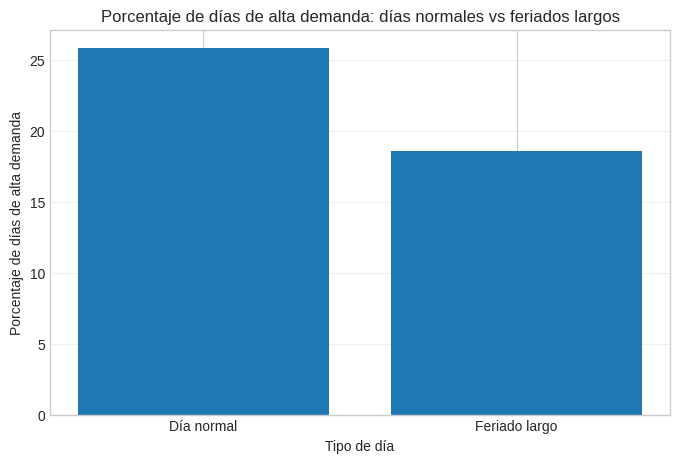

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    alta_demanda_feriados['tipo_dia'],
    alta_demanda_feriados['porcentaje_alta_demanda']
)

plt.title('Porcentaje de días de alta demanda: días normales vs feriados largos')
plt.xlabel('Tipo de día')
plt.ylabel('Porcentaje de días de alta demanda')
plt.grid(axis='y', alpha=0.3)

plt.show()

Se definió como día de alta demanda a aquellos días que se encuentran dentro del 25% con mayor cantidad de pasajeros. Esta clasificación permite transformar el análisis predictivo en una herramienta de alerta para la empresa. Si un día futuro presenta características similares a los días de alta demanda, la empresa podría anticipar refuerzos en personal, transporte, atención al pasajero y coordinación operativa.

## Ejemplos de escenarios

In [40]:
# Simulación de escenarios futuros con el modelo de calendario

escenarios = pd.DataFrame({
    'mes': [1, 7, 7, 10, 12],
    'dia_semana_num': [2, 5, 6, 5, 4],
    'es_fin_de_semana': [0, 1, 1, 1, 0],
    'es_feriado_largo': [0, 0, 1, 1, 1]
})

escenarios['descripcion'] = [
    'Día normal de enero',
    'Sábado de julio',
    'Domingo de julio en feriado largo',
    'Sábado de octubre en feriado largo',
    'Viernes de diciembre en feriado largo'
]

# Reordenamos columnas para predecir
X_escenarios = escenarios[
    [
        'mes',
        'dia_semana_num',
        'es_fin_de_semana',
        'es_feriado_largo'
    ]
]

escenarios['pasajeros_estimados'] = modelo_calendario.predict(X_escenarios)

display(escenarios[['descripcion', 'pasajeros_estimados']])

,descripcion,pasajeros_estimados
0,Día normal de enero,3631.727053
1,Sábado de julio,6167.443325
2,Domingo de julio en feriado largo,4448.849748
3,Sábado de octubre en feriado largo,3910.804667
4,Viernes de diciembre en feriado largo,3496.532015


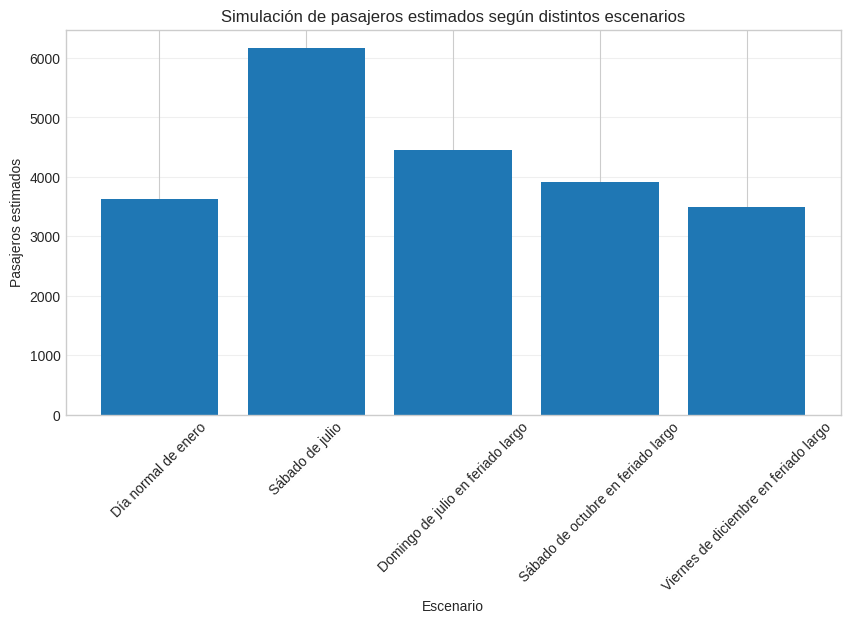

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    escenarios['descripcion'],
    escenarios['pasajeros_estimados']
)

plt.title('Simulación de pasajeros estimados según distintos escenarios')
plt.xlabel('Escenario')
plt.ylabel('Pasajeros estimados')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

A partir de los modelos predictivos desarrollados, se observa que la demanda aérea hacia Bariloche está fuertemente influenciada por la estacionalidad mensual. Esto significa que la empresa debe prestar especial atención a los meses de mayor movimiento turístico, principalmente aquellos vinculados con temporada alta.

Si bien los feriados largos no aparecen como la variable más influyente del modelo, siguen siendo relevantes para la planificación operativa, ya que pueden coincidir con períodos de alta demanda. Por este motivo, se recomienda utilizar el modelo como una herramienta de alerta temprana para anticipar días críticos.

La empresa podría aplicar este tipo de predicción para reforzar personal, mejorar la atención al pasajero, coordinar mejor los servicios de transporte y anticipar posibles saturaciones durante fechas turísticas clave.

## Limitaciones del modelo predictivo

Si bien los modelos desarrollados permiten estimar la demanda diaria de pasajeros en Bariloche, deben interpretarse como una herramienta de apoyo para la toma de decisiones y no como una predicción exacta.

Una limitación importante es que el modelo utiliza principalmente variables de calendario, como mes, día de la semana, fin de semana y feriado largo. Sin embargo, la demanda aérea también puede verse afectada por otros factores que no están incluidos en el dataset, como condiciones climáticas, precios de pasajes, cancelaciones, promociones turísticas, eventos especiales, capacidad de alojamiento y decisiones operativas de las aerolíneas.

Además, en el primer modelo la variable cantidad de vuelos tiene una influencia muy alta, lo cual es lógico porque a mayor cantidad de vuelos suele haber mayor cantidad de pasajeros. Por eso también se construyó un modelo alternativo sin esa variable, para observar mejor el efecto de la estacionalidad y de los feriados largos.



## Recomendaciones

A partir de los resultados, se recomienda planificar los recursos considerando principalmente la **temporada del año y la cantidad de vuelos programados**. Durante julio y agosto sería conveniente reforzar el transporte terrestre, el personal y los servicios de atención, especialmente en los días y horarios de mayor actividad.

Los feriados largos no deberían utilizarse como único criterio de planificación, ya que en los datos analizados no generaron por sí solos un aumento de la demanda. Pueden considerarse como información adicional, junto con el mes, el día de la semana y la programación de vuelos.

El modelo predictivo puede emplearse como una herramienta de apoyo para anticipar días de alta demanda. Sin embargo, sus estimaciones deben combinarse con información actualizada de vuelos, condiciones meteorológicas y eventos turísticos.

# Conclusiones del caso Bariloche

La elección de Bariloche se justifica porque la ruta **Ciudad de Buenos Aires-San Carlos de Bariloche** fue la de mayor cantidad de pasajeros del ranking analizado.

Entre 2023 y 2025 se registraron, en promedio, **6.873 movimientos diarios de pasajeros**, con un desvío estándar de **2.078**. Esto muestra que la demanda cambia bastante según el momento del año, por lo que no alcanza con planificar únicamente a partir del promedio.

La mayor actividad se concentró durante el invierno. **Agosto** alcanzó un promedio de **9.958 movimientos diarios**, mientras que los sábados fueron los días con más pasajeros que aterrizan. El modelo normal también dio una aproximación razonable: estimó que el **68,27%** de los días de agosto estaría dentro del intervalo habitual calculado, frente al **66,67%** observado.

En los modelos predictivos, la **cantidad de vuelos** fue la variable más importante. Al analizar solamente variables de calendario, el **mes** concentró cerca del **85%** de la importancia. En cambio, los feriados largos no mostraron por sí solos un aumento de la demanda: incluso al comparar dos escenarios iguales, cambiar únicamente la condición de feriado produjo una diferencia estimada de apenas **−9 pasajeros**.

En conclusión, para organizar el transporte terrestre, el personal y los servicios del aeropuerto conviene considerar principalmente la temporada, el día de la semana y la cantidad de vuelos previstos. En los datos analizados, estas variables resultaron más útiles que el hecho de que una fecha fuera o no un feriado largo.

# Conclusiones generales

A nivel nacional se comprobó que la demanda cambia según el mes, el día y la hora. También se encontraron niveles elevados de ocupación y una proporción importante de vuelos con demoras, especialmente en las partidas. Además, el modelo de Poisson no representó correctamente las demoras nacionales, lo que demuestra que un modelo matemático debe contrastarse siempre con los datos observados.

La elección de Bariloche surgió del propio análisis: la ruta **Ciudad de Buenos Aires-San Carlos de Bariloche** fue la de mayor cantidad de pasajeros del ranking estudiado. Al analizar el aeropuerto con mayor detalle, se observó que la demanda está marcada principalmente por la temporada. Los meses de invierno, la cantidad de vuelos y algunos días de la semana aportaron más información para anticipar el movimiento que la presencia de un feriado largo.

Los modelos normal, binomial y Poisson permitieron estudiar diferentes situaciones de demanda. No deben entenderse como predicciones exactas, sino como herramientas para estimar escenarios habituales o la probabilidad de que se presenten días con varios movimientos de alta demanda. El modelo predictivo confirmó, además, que conocer la cantidad de vuelos mejora considerablemente la estimación de pasajeros.

Estos resultados pueden utilizarse para decidir cuándo reforzar el transporte terrestre, el personal y los servicios del aeropuerto. Para Bariloche, la planificación debería concentrarse especialmente en julio y agosto, en los días de mayor movimiento y en la programación prevista de vuelos. Los feriados pueden considerarse como información adicional, pero no como el único criterio para organizar recursos.

Finalmente, las conclusiones están limitadas por los datos disponibles. Las fuentes poseen diferentes estructuras y períodos, algunos valores fueron imputados y no se incorporaron factores como el clima, los precios, las cancelaciones o los eventos turísticos. Además, cuando se suman aterrizajes y despegues se analizan movimientos registrados de pasajeros y no personas únicas que llegan a la ciudad. Por lo tanto, los resultados sirven como apoyo para la toma de decisiones, pero deben complementarse con información operativa actualizada.

# Limitaciones generales

Los resultados deben interpretarse considerando las siguientes limitaciones:

- **Diferencias entre fuentes:** los datasets de conectividad, ANAC y Failbondi tienen distintos períodos, estructuras y niveles de agregación, por lo que no siempre permiten comparaciones directas.

- **Períodos incompletos:** los datos de 2026 de ANAC están disponibles únicamente hasta abril. Por este motivo, no se utilizan para comparaciones anuales completas.

- **Representatividad de las demoras:** Failbondi puede no incluir la totalidad de los vuelos operados en Argentina y depende de su propia metodología de recopilación.

- **Tratamiento de valores extremos:** para analizar las demoras se conservaron valores entre -180 y 360 minutos. Esta decisión evita que casos aislados distorsionen los resultados, pero excluye operaciones extremas que podrían ser reales.

- **Valores imputados:** algunos registros sin información de ocupación fueron completados utilizando la media de su clasificación. Aunque representan una proporción pequeña, son valores estimados.

- **Pasajeros y movimientos:** en algunos análisis de Bariloche se consideran conjuntamente aterrizajes y despegues. En esos casos, los resultados representan movimientos de pasajeros registrados y no personas únicas que llegan a la ciudad.

- **Variables externas:** no se incorporaron factores como clima, precios de pasajes, cancelaciones, promociones turísticas, eventos, capacidad hotelera o decisiones operativas de las aerolíneas.


# Bibliografía
- Administración Nacional de Aviación Civil. (s. f.). Aterrizajes y despegues procesados por la Administración Nacional de Aviación Civil (ANAC) [Conjunto de datos]. Datos Argentina. Recuperado el 20 de mayo de 2026, de https://datos.gob.ar/dataset/transporte-aterrizajes-despegues-procesados-por-administracion-nacional-aviacion-civil-anac
- Datos Argentina. (s. f.). Datos Argentina: Portal nacional de datos públicos. Recuperado el 20 de mayo de 2026, de https://www.datos.gob.ar/

- Failbondi. (s. f.). Acerca de Failbondi. Recuperado el 20 de mayo de 2026, de https://failbondi.fail/acerca

- Tableros Yvera. (s. f.). Conectividad aérea. Recuperado el 20 de mayo de 2026, de https://tableros.yvera.tur.ar/conectividad/

- Material de clase de Matemática IV e Introducción a Ciencia de Datos. (2026). 

- Martin-Rodriguez, G., & Caceres-Hernandez, J. J. (2023). Seasonal variations in daily data: An application to air passenger arrivals. Journal of Air Transport Management, 110, Article 102419. https://doi.org/10.1016/j.jairtraman.2023.102419

- Chudy-Laskowska, K., & Pisula, T. (2017). Seasonal forecasting for air passenger traffic. En 4th International Multidisciplinary Scientific Conference on Social Sciences & Arts SGEM 2017 (pp. 681–692). https://doi.org/10.5593/sgemsocial2017/14/S04.089

- Serrano Ortega, A., Ruiz Martín, A., & Argerich Martín, C. (2026). Air traffic demand forecasting for origin–destination airport pairs using artificial intelligence. Engineering Proceedings, 133(1), Article 25. https://doi.org/10.3390/engproc2026133025

- Blasco-Puyuelo, J., Burrieza-Galán, J., Cantú-Ros, O. G., Herranz, R., & Mocholí, D. (2023). A machine learning approach for predicting airport passenger flows. En Proceedings of the 2023 SESAR Innovation Days. https://doi.org/10.61009/SID.2023.1.37
